# Case study: Estimating the orbit of _Beta Pictoris b_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import norm, uniform
import emcee
import tqdm
import corner
from multiprocessing import Pool
import kepler
import pickle


In [2]:
# Fill in this cell with your personal details:
# - Name: Mertens Vincent
# - Student ID: s171252
# - Email: Vincent.Mertens@student.uliege.be

Deadline: December 19th 2025.

Instructions:
- Submit your completed notebook on Gradescope.
- All cells must be executable and their outputs should not be erased before submission.
- This case study must be carried out alone. You are not allowed to discuss or collaborate with other students.
- In January, you will have to explain and defend your solution during a 30-minute oral exam.
- This case study (including its defense in January) will account for 50% of the final grade.

Comments:
- Solve the case study below by following the Bayesian workflow as best as possible.
- Follow the data visualization principles to make your plots effective and readable.
- Make the best use of the Python scientific ecosystem.
- Add comments to explain your reasoning, choices, and interpretations.
- You can add additional cells as needed.

# Introduction

Beta Pictoris is a young star located approximately 63 light-years from Earth in the constellation Pictor. It has been a target of intense astronomical study since the 1980s, when astronomers discovered a large debris disk surrounding the star. In 2008, astronomers using direct imaging techniques discovered a giant exoplanet orbiting Beta Pictoris, named _Beta Pictoris b_.

Since its discovery, _Beta Pictoris b_ has been observed multiple times using various telescopes and instruments tracking its position relative to the host star. These observations have provided valuable data on the planet's orbit, which is crucial for understanding its formation and evolution, as well as the dynamics of the surrounding debris disk.

Your goal in this case study is to exercise your Bayesian data analysis skills to estimate the orbit of _Beta Pictoris b_ using the available astrometric data.

<div align="center">
<img src="./betapicb.gif" alt="Beta Pictoris system" width="500">
<p><i>Credit: Gemini Planet Imager, VLT/NACO, and VLT/SPHERE.</i></p>
</div>

# Data Exploration

<div class="alert alert-success">
    
**Q1**. Load the astrometric data from `beta_pic_b_sep_pa.csv` into a Pandas DataFrame.
    
</div>

In [3]:
df = pd.read_csv("beta_pic_b_sep_pa.csv")

<div class="alert alert-success">
    
**Q2**. Explore the dataset and report relevant insights.
    
</div>

In [4]:
df.head()

,epoch,sep,sep_err,pa,pa_err
0,54781,210.0,27.0,211.49,1.9
1,52953,413.0,22.0,34.00,4.0
2,55129,299.0,14.0,211.00,3.0
3,55194,306.0,9.0,212.10,1.7
4,55296,346.0,7.0,209.90,1.2


In [5]:
df.describe()

,epoch,sep,sep_err,pa,pa_err
count,34.000000,34.000000,34.000000,34.000000,34.000000
mean,56189.000000,358.779412,6.473529,195.976176,1.028235
std,1087.357542,91.559829,6.413164,52.346781,0.919827
min,52953.000000,141.900000,0.900000,28.160000,0.150000
25%,55516.250000,308.825000,1.025000,210.850000,0.225000
50%,56139.000000,388.500000,5.000000,212.000000,0.650000
75%,56886.000000,428.325000,10.000000,212.745000,1.700000
max,58440.000000,470.000000,27.000000,214.840000,4.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   epoch    34 non-null     int64  
 1   sep      34 non-null     float64
 2   sep_err  34 non-null     float64
 3   pa       34 non-null     float64
 4   pa_err   34 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.5 KB


Text(0, 0.5, 'Position angle [degrees]')

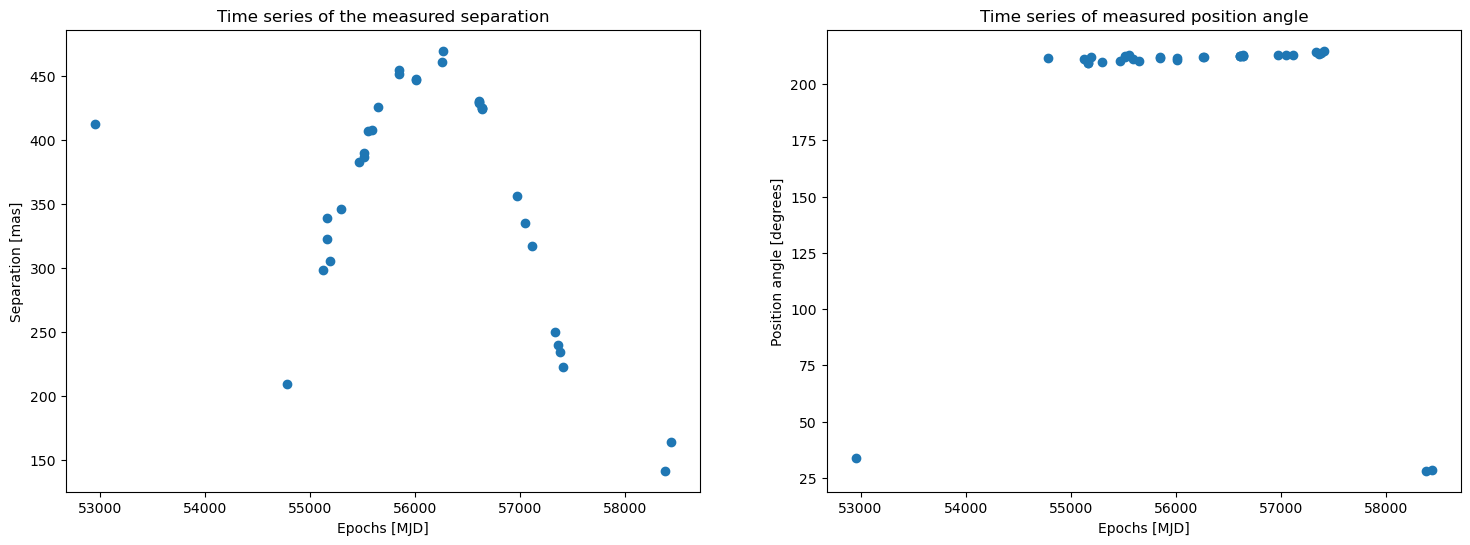

In [7]:
fig, axs = plt.subplots(1,2, figsize=(18,6))

axs[0].set_title("Time series of the measured separation")
axs[1].set_title("Time series of measured position angle")

axs[0].scatter(df["epoch"], df["sep"])
axs[1].scatter(df["epoch"], df["pa"])

axs[0].set_xlabel("Epochs [MJD]")
axs[0].set_ylabel("Separation [mas]")

axs[1].set_xlabel("Epochs [MJD]")
axs[1].set_ylabel("Position angle [degrees]")

Text(0.5, 0, 'Error on the position angle')

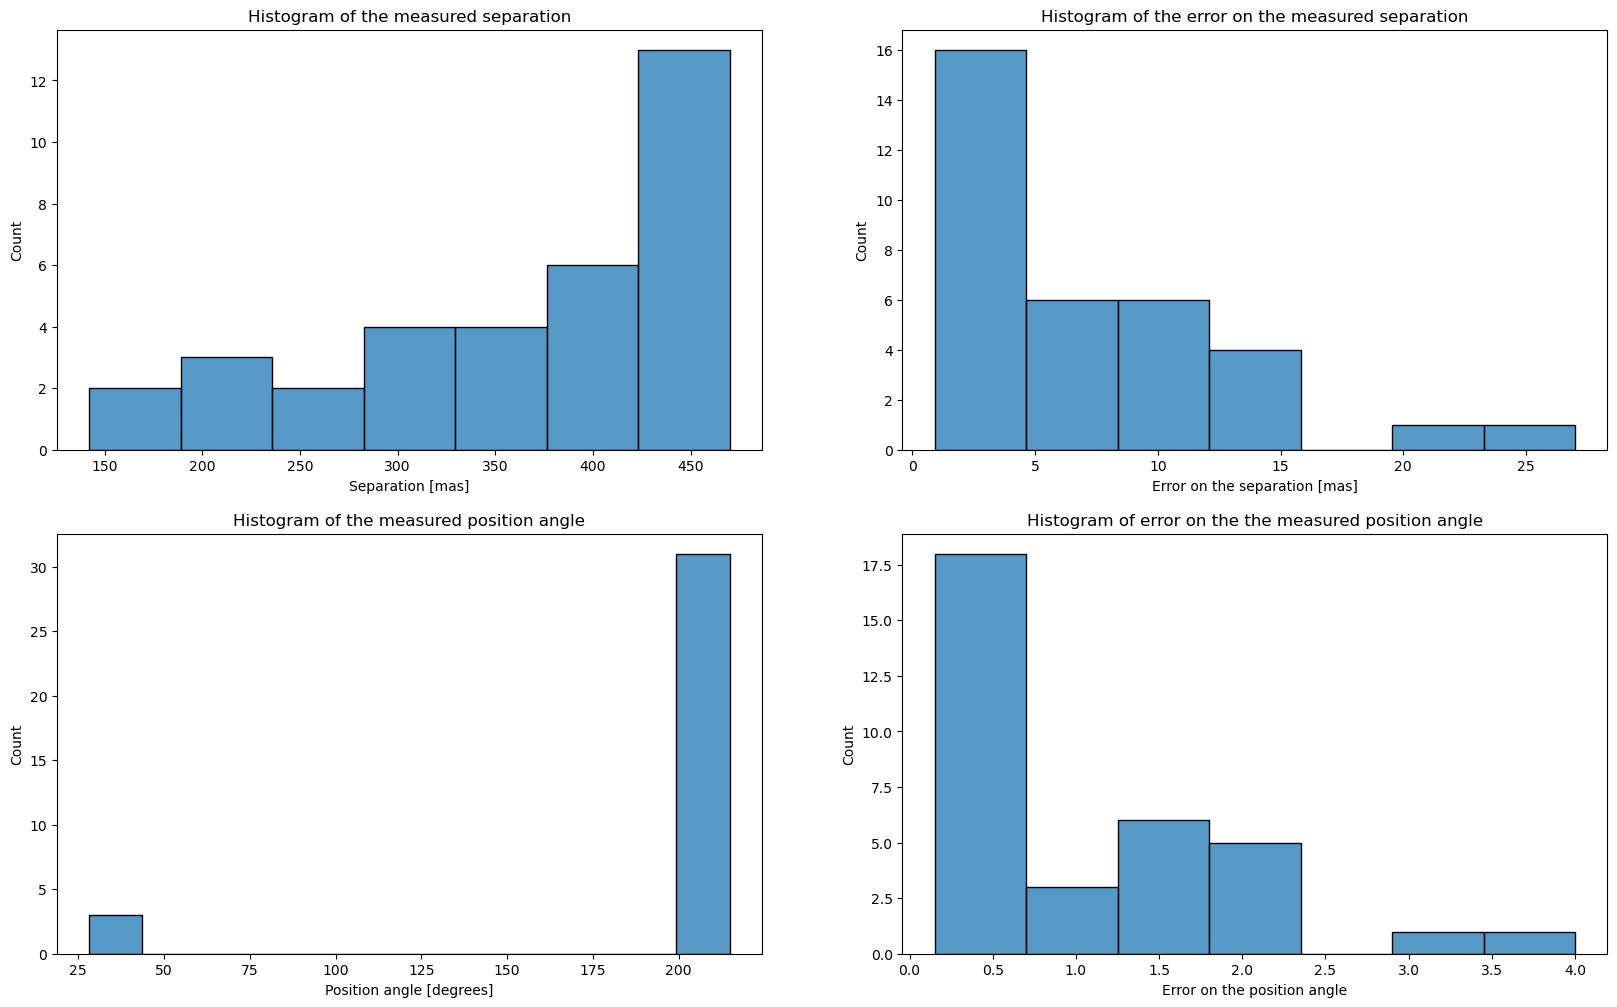

In [8]:
fig, axs = plt.subplots(2,2, figsize=(20,12))

axs[0,0].set_title("Histogram of the measured separation")
axs[0,1].set_title("Histogram of the error on the measured separation")
axs[1,0].set_title("Histogram of the measured position angle")
axs[1,1].set_title("Histogram of error on the the measured position angle")


sns.histplot(df["sep"], ax=axs[0,0])
sns.histplot(df["sep_err"], ax=axs[0,1])
sns.histplot(df["pa"], ax=axs[1,0])
sns.histplot(df["pa_err"], ax=axs[1,1])

axs[0,0].set_xlabel("Separation [mas]")
axs[0,1].set_xlabel("Error on the separation [mas]")
axs[1,0].set_xlabel("Position angle [degrees]")
axs[1,1].set_xlabel("Error on the position angle")

__Quick check of the data__\
\
The data provided is composed of 5 columns:
- "epoch": The date at which the observations were taken
- "sep": The measured separation
- "sep_err": The error associated to the measured separation
- "pa": The measured position angle
- "pa_err": The error associated to the position angle

None of the column contain any NaN values. We could argue that the error associated to the measured are far smaller than them, outlining the quality of the data (in general).\
The position angle lying aroung 25-50 degrees or 200 degrees may hint towards the seasonality of the observation. However, the amout of observation corresponding to the 25-50 degrees only represent 3/34 or ~ 9% of the observations. This reasoning might just only be an educated supposition.\
\
Thanks to the plot of the timeseries (in epochs), we can easily distinguish the cyclic characteristic appearance of an orbit: The augmentation then diminution of the separation coupled with the change of position angle (from 30 to 210 degrees back and forth). The change of position angle can be seen as the transition into the oposite trigonometric quadrant if we look at the orbit face on.

# Build: Keplerian orbits

We recommend watching the following [video](https://www.youtube.com/watch?v=yn_Nto4Bd48) for a visual explanation of Keplerian orbits and their parameters but provide a summary below.

The motion of Beta Pictoris b around its star follows Kepler's laws of planetary motion. A full three-dimensional orbit is defined by eight orbital parameters that describes its shape and orientation:

- **Semi-major axis** ($a$): half of the long axis of the ellipse [AU]<sup>(1)</sup>. The short axis (semi-minor), is related to the semi-major axis and eccentricity by $b = a \sqrt{1 - e^2}$.
- **Eccentricity** ($e$): how elongated the ellipse is (e $\in [0, 1]$).
- **Inclination** ($i$): tilt of the orbital plane w.r.t reference plane which is the plane perpendicular to the line of sight from Earth to the star (in degrees or radians).
- **Argument of periapsis** ($\omega$): the periapsis is the point where the planet is closest to the star. All orbital angles are measured relative to that point. The argument of periapsis defines the angle from the ascending node (the point where the planet crosses the reference plane going "up") to the periapsis (in radians).
- **Position angle of ascending node** ($\Omega$): the rotation of the orbital plane around the line of sight (in radians). It orients the orbital plane on the sky.
- **Time of periapsis** ($\tau$): what fraction of the orbital period ago was the last periapsis passage (in fraction of period, between 0 and 1).
- **Parallax** ($\Pi$): the angular shift of the star due to Earth's orbit, which tells us the distance to the star [mas]<sup>(2)</sup>.
- **Total mass** ($M_T$): the combined mass of the star and planet (in solar masses [$M_\odot$]).

<div align="center">
<img src="./kepler_arguments.png" alt="Kepler parameters illustration" width="500">
<p><i>Kepler parameters. Credit: Sun et al. (2022), arxiv:2201.08506</i></p>
</div>

From these parameters, we first derive the orbital period $P$ (in years) using Kepler's third law:
$$\begin{align*}
(\frac{P}{1 \text{ year}})^2 &= (\frac{a}{1 \text{ au}})^3 \; \left(\frac{M_T}{ 1 \; M_\odot}\right)^{-1}.
\end{align*}$$

The angular offsets $\Delta \mathrm{RA}$ and $\Delta \mathrm{Dec}$ at each observation epoch $t$ of the planet relative to the host star on the reference plane can then be computed using Kepler's equations through intermediate angular quantities called anomalies. The term "anomaly" is a historical term meaning angles measured from reference directions. We have three types of anomalies:

- Mean anomaly
$$ \begin{align*}
M = 2\pi \Big(\frac{t - t_{\text{ref}}}{P} - \tau\Big),
\end{align*}
$$
which increases uniformly with time. It tracks orbital phase as if the planet moved at constant speed. $t_{\text{ref}}$ is a reference epoch for $\tau$ (here $t_{\text{ref}} = 50000 [MJD]$ <sup>(3)</sup>, which corresponds to 1995-10-10).
- Eccentric anomaly ($E$): an auxiliary angle defined implicitly by Kepler’s equation ($M = E - e\sin E$). $E$ cannot be computed analytically (i.e., no closed form algebraic solution exists), so we will need to solve it numerically (e.g., using the Newton-Raphson method).
- True anomaly ($\nu$): the geometric angle locating the planet along the orbit, related to $E$ by
$$\begin{align*}
\nu &= 2 \arctan \left( \sqrt{\frac{1+e}{1-e}} \tan \frac{E}{2} \right).
\end{align*}$$

$M$, $E$, and $\nu$ are not parameters but computed intermediate angles.

From these, we can finally derive the angular offsets of the planet relative to the star. Projecting the orbit into the observer's frame, we have:

$$ \begin{align*}
\Delta \mathrm{RA} &= \Pi a (1 - e \cos E) \left[\cos^2 \frac{i}{2} \; \sin(\nu + \omega + \Omega) - \sin^2 \frac{i}{2} \; \sin(\nu + \omega - \Omega)\right], \\
\Delta \mathrm{Dec} &= \Pi a (1 - e \cos E) \left[\cos^2 \frac{i}{2} \; \cos(\nu + \omega + \Omega) + \sin^2 \frac{i}{2} \; \cos(\nu + \omega - \Omega)\right].
\end{align*} $$

$\Delta\mathrm{RA}$ and $\Delta\mathrm{Dec}$ are angular displacements, not physical distances:
one measures how far east–west, the other north–south, the planet appears from the star.
The $\Delta$ symbol indicates that these are relative to the star’s position, not absolute celestial coordinates.
They depend only on orbital geometry and orientation, not on detector properties except for calibration.

However, telescopes do not directly measure Cartesian angular offsets $(\Delta\mathrm{RA},\Delta\mathrm{Dec})$. Instead, they measure two polar quantities:

- Separation (sep): the apparent angular distance between the star and planet,
- Position angle (PA): the direction of that offset, measured east of north.

These are related to the Cartesian offsets by the following equations:
$$ \begin{align*}
\Delta \mathrm{RA} &= \text{sep} \times \sin(\text{PA}), \\
\Delta \mathrm{Dec} &= \text{sep} \times \cos(\text{PA}).
\end{align*} $$

Converting between the two allows a direct comparison between the theoretical orbit and the observed astrometric data.

---

(1): Astronomical Unit (AU) is the average distance between the Earth and the Sun, approximately 149.6 million kilometers.

(2): Milliarcseconds (mas), where 1 arcsecond = 1/3600 degrees, and 1 mas = 1/1000 arcseconds.

(3): Modified Julian Date (MJD) is a continuous count of days since midnight on November 17, 1858. It is commonly used in astronomy to simplify date calculations.


<div class="alert alert-success">
    
**Q3**. Implement `solve_kepler` and `compute_orbit` functions to compute the predicted $\Delta \mathrm{RA}$ and $\Delta \mathrm{Dec}$ at given times (epochs). 
    
</div>

For this part, we make use of the Newton-Raphosn formula method. This method is used to resolve equations of shape $f(x)=0$.\
\
We start by stating an initial approximation of $x \Rightarrow x_0$\
We then improve itteratiely this statement with the local tangent as $x_{n+1}=x_n -\frac{f(x_n)}{f'(x_n)}$\
\
For this method, we start with an initial estimation of $E_0 = M + ecc \times sin(M)$, which is mathematically correct for $e<<1$. We will also state that for high eccentricity (ellipticity) this approximation can worsen and lead to a slower convergence.\
\
\
About the second function, compute_orbit, we work progressively, computing parameters after parameters to end up with the desired predicted separation and position angle. The computation will be done in this order:
- Orbital period ($P$)
- Mean anomally ($M$)
- Eccentric anomaly ($E$)
- TRue anomaly ($\nu$)
- Angular offset ($\Delta RA$, $\Delta Dec$)
- Separation ($sep$) and position angle ($PA$)

In [9]:
def solve_kepler(M, ecc, tolerance=1e-8, max_itt=100):
    """
    Solve Kepler's equation: M = E - ecc*sin(E) for eccentric anomaly E.
    
    Parameters:
    -----------
        - M: mean anomaly in radians
        - ecc: eccentricity (0 <= ecc < 1)

    Returns:
    --------
        - E: eccentric anomaly in radians
    """
    # Initialisation of the first value of E
    E = M + ecc * np.sin(M)

    for i in range(max_itt):
        
        f = E - ecc*np.sin(E) - M        #Initial function
        f_prime = 1 - ecc*np.cos(E)      #Derivation of this function

        if abs(f_prime) < 1e-12:         #To avoid division by numbers too close to 0
            E += 1e-8
            continue

        E_new = E - (f/f_prime)          #Formula of Newton-Raphson

        if abs(E_new - E) <= tolerance:
            
            return E_new
        
        E = E_new

    raise RuntimeError("The solution proposed by the Newton-Raphson method has not converged within the given itteration range")
    

    
def compute_orbit(epochs, sma, ecc, inc, aop, pan, tau, plx, mtot, t_ref=50000.0):
    """
    Calculate predicted separation and position angle from Keplerian orbital elements
    
    Parameters:
    -----------
        - epochs: array of observation epochs (t1, t2, ..., tn) in [MJD]
        - sma: semi-major axis [AU]
        - ecc: eccentricity [0, 1]
        - inc: inclination [radians]
        - aop: argument of periastron (omega) [radians]
        - pan: position angle of nodes (Omega) [radians]
        - tau: epoch of periastron passage (fraction of period)
        - plx: parallax [mas]
        - mtot: total system mass [solar masses]
        - t_ref: reference epoch [MJD]

    Returns:
    --------
        - sep: predicted separation [mas]
        - pa: predicted position angle [°]
    """

    # Orbital period
    P = np.sqrt((sma**3)/mtot)
    P_days = P * 365.25  # Conversion in days to keep the same unit later on

    # Mean anomaly
    M = np.array([2 * np.pi * (((epoch - t_ref) / P_days) - tau) for epoch in epochs])
    M = np.mod(M, 2*np.pi)    # Reducted angle as an angle of 3 pi is the same as an angle of pi in this case.

    # Eccentric anomaly
    E = np.array([solve_kepler(M_epoch, ecc) for M_epoch in M])

    # True anomaly
    nu = 2 * np.arctan(np.sqrt((1+ecc)/(1-ecc)) * np.tan(E/2))

    # Anguler offsets
    r = plx * sma * (1 - ecc*np.cos(E))

    delta_RA = r * ((np.cos(inc/2)**2 ) * np.sin(nu + aop + pan) - 
                    (np.sin(inc/2)**2 ) * np.sin(nu + aop - pan))
    
    delta_dec = r * ((np.cos(inc/2)**2 ) * np.cos(nu + aop + pan) + 
                     (np.sin(inc/2)**2 ) * np.cos(nu + aop - pan))

    # Result
    pa = np.rad2deg(np.arctan2(delta_RA, delta_dec)) % 360
    sep = sep = np.sqrt(delta_RA**2 + delta_dec**2)

    return sep, pa

In the case that the Newton-Raphson does not converge, we simply raise an error. This will be usefull later on to compute the likelihood.\
\
We can show the accuracy of this function by compairing in with another function used for orbital computation and originating from the package "kepler.py", a fast solver derived from the exoplanet package [ref here](https://pypi.org/project/kepler.py/). We do not use it here but can use it to asses the accuracy of our function.

In [10]:
# We define here the atual values taken from the scientific literature exisitng on Beta pictoris b
sma = 10.03
ecc = 0.10
inc = np.deg2rad(88.9)
aop = np.deg2rad(212.5)
pan = np.deg2rad(31.77)
tau = 0.78          # fraction of period
plx = 51.44        # mas
mtot = 1.75        # solar masses


t_ref = 50000.0
epochs = df["epoch"]  # example epoch in MJD

In [11]:

P = np.sqrt((sma**3)/mtot)
P_days = P * 365.25 

M = np.array([2 * np.pi * (((epoch - t_ref) / P_days) - tau) for epoch in epochs])
M = np.mod(M, 2*np.pi)

E_self = np.array([solve_kepler(M_epoch, ecc) for M_epoch in M])

E_kepler = np.array([kepler.solve(M_epoch, ecc) for M_epoch in M])

diff = np.sum(E_self - E_kepler)

print(f'The summed difference on all the given epochs is {diff}')

The summed difference on all the given epochs is -3.1363800445660672e-15


In [12]:
# Limit testing
test_cases = [
    (0.0, 0.5),      # M=0
    (np.pi, 0.5),    # M=π
    (0.1, 0.0),      # ecc=0 (circular)
    (0.1, 0.9),      # high eccentricity
]

for M_test, ecc_test in test_cases:
    E_k = kepler.solve(M_test, ecc_test)
    E_nr = solve_kepler(M_test, ecc_test)
    print(f"M={M_test:.2f}, ecc={ecc_test:.2f} → diff={abs(E_k - E_nr):.2e}")

M=0.00, ecc=0.50 → diff=0.00e+00
M=3.14, ecc=0.50 → diff=0.00e+00
M=0.10, ecc=0.00 → diff=0.00e+00
M=0.10, ecc=0.90 → diff=4.44e-16


<div class="alert alert-success">
    
**Q4**. Implement a Bayesian model with:

- **Prior** $p(\theta)$ on the orbital parameters $\theta = (a, e, i, \omega, \Omega, \tau, \Pi, M_{tot})$. Hint: The parallax $\Pi$ and total mass $M_{tot}$ can be constrained using existing measurements of the host star Beta Pictoris.
    - Define appropriate prior distributions for each orbital parameter.
    - Guide your choices with prior predictive checks and adjust as needed.

- **Likelihood** $p((\text{sep}_{t_1}, \text{pa}_{t_1}), ..., (\text{sep}_{t_n}, \text{pa}_{t_n})|\theta)$ that models the measured separations [mas] and position angles [degrees] given the orbital parameters $\theta$. Epochs $t_1, \ldots, t_n$ correspond to the times of the observations. Gaussian errors are assumed for both measurements, with standard deviations given by `sep_err` and `pa_err` for each epoch.

Define functions both for evaluating the log densities and for sampling from the prior and likelihood at given epochs and standard deviations.
    
</div>

### Prior

In order to initialize appropriate prior distributions, whose validity is assessed through prior predictive checks, we distinguish between two types of priors.\
\
__Informed prior__: They correspond to parameters that are constrained by independent measurements available in the literature. These parameters are sampled from normal distributions centered on the measured values.\
\
__Uninformed prior__: They are assigned to parameters that are not directly measured independently, but whose values are physically or mathematically bounded. These priors are chosen to be weakly informative, allowing the data to primarily constrain the posterior distributions.\
\
It is important to note that using literature values as informed priors can lead to double counting of information if these values are derived from the same type of observations used in the likelihood. To avoid introducing biases, parameters are only assigned informed priors when their constraints originate from observations independent of the astrometric data modeled here. This approach ensures sufficient flexibility in the model and prevents the posterior from being artificially driven toward predefined values.

Here, we use strongly informative priors for parallax, total mass and semi-major axis as they are based on independant observation constrains (Gaia observation, stellar models). For the other geometric parameters we adopt weakly informative (or just uninformative) priors that are physically motivated but broad enough so that the data will dominate the posterior. We will not __force__ the model to output the real/known value.\
\
In oter words, the parallax, total mass and sma have tight normal distribution to reflect high-precision external measurments while the other orbital parameters have uniform priors to limit their influence on the inference.

- __Semi-major axis__: Gaussian centered around the true value. Maybe too informed but I did not find a justification for a bounded uniform distribution. As amelioration, a uniform distribution bounded by the order coul dbe investigated (_e.g._ 1-100 ?)

- __Eccentricity__: Scientiically bounded $[0,1]$ with a uniform distribution. However, for multi-planetar system, the mean eccentricity is around $0.1$ against $0.3$ for unique system. For this reason, a uniform distribution bounded as $[1e(-6), 0.99]$ is justified. We chose a number higher than 0 to avoid error in the computations later on (walker exploring wrong part of the space). Because it correspond to a perfectly circular orbit, it is not likely anyway.

- __Inclination__: Bounded uniformally between $0$ and $180°$ (converted in radians so $0$ to $\pi$). 

- __AOP and PAN__: Both complete angle in radian thus $[0, 2\pi]$

- __Tau__: Fraction of period so by definition bounded between $0$ and $1$.

- __Plx and Mtot__: These measurments are constrained by the star and not the exoplanet. In any case the total mas is highly dominated by the mass of the star and the parallax is the same for the two bodies (as they are close from one another). For these reason, assuming a gaussian distribution around the scientific value makes sens and correspond to defining our system (_e.g._ "we are looking at a system at this distance and of this mass")

In [13]:
def sample_prior():
    """
    Sample n times from a defined prior distribution for each orbital parameter.
    
    Reutrns:
    -----------
        - sma: semi-major axis [AU]
        - ecc: eccentricity [0, 1]
        - inc: inclination [radians]
        - aop: argument of periastron (omega) [radians]
        - pan: position angle of nodes (Omega) [radians]
        - tau: epoch of periastron passage (fraction of period)
        - plx: parallax [mas]
        - mtot: total system mass [solar masses]

    """

    sma = np.random.normal(10.03, 5)   # Leave a bit of freedom
    ecc = np.random.uniform(10**(-6), 0.99)
    inc = np.random.uniform(0, np.pi)
    aop = np.random.uniform(0, 2 * np.pi)
    pan = np.random.uniform(0, 2 * np.pi)
    tau = np.random.uniform(0, 1)
    plx = np.random.normal(51.44, 0.12)
    mtot = np.random.normal(1.75, 0.5)

    return sma, ecc, inc, aop, pan, tau, plx, mtot


In [14]:
def prior_predictive_check(observations, sample):
    """
    Compute prior predictive checks, combining our defined prior distribution and the given observations.

    Parameters:
    ----------
        - observations: pandas.DataFrame containing the measurments of separation, position angle and their associated error

    """
    
    sep, pa = compute_orbit(observations["epoch"], *sample)

    sep_noisy = sep + np.random.normal(0, observations["sep_err"].values, size=sep.shape)
    pa_noisy = pa + np.random.normal(0, observations["pa_err"].values, size=pa.shape)



    # Plot

    fig, axs = plt.subplots(2,2, figsize=(20,12))

    #----------TIME SERIES---------------

    # Separation
    axs[0,0].scatter(observations["epoch"], sep_noisy, alpha=0.5, color="blue", label="Predictions")
    
    axs[0,0].scatter(observations["epoch"], observations["sep"], alpha=0.5, color="red", label="Observations")
    axs[0,0].set_xlabel("Epochs [MJD]")
    axs[0,0].set_ylabel("Separation [mas]")
    axs[0,0].set_title("Separation - Timeseries")
    axs[0,0].legend()
    axs[0,0].grid(alpha=0.3)

    # Position angle
    axs[0,1].scatter(observations["epoch"], pa_noisy, alpha=0.5, color="blue", label="Predictions")
    
    axs[0,1].scatter(observations["epoch"], observations["pa"], alpha=0.5, color="red", label="Observations")
    axs[0,1].set_xlabel("Epochs [MJD]")
    axs[0,1].set_ylabel("Position angle [degrees]")
    axs[0,1].set_title("Position angle - Timeseries")
    axs[0,1].legend()
    axs[0,1].grid(alpha=0.3)

    #-------------HISTOGRAM---------------

    # Define fixed bin for the sep
    sep_min = min(sep_noisy.min(), observations["sep"].min())
    sep_max = max(sep_noisy.max(), observations["sep"].max())
    sep_bins = np.linspace(sep_min, sep_max, 30)

    pa_min = min(pa_noisy.min(), observations["pa"].min())
    pa_max = max(pa_noisy.max(), observations["pa"].max())
    pa_bins = np.linspace(pa_min, pa_max, 30)



    # Separation
    sns.histplot(sep_noisy.flatten(), bins=sep_bins, alpha=0.5, label="Predictions", stat="density", color="blue", ax=axs[1,0])
    sns.histplot(observations["sep"].values, bins=sep_bins, alpha=0.5, label="Observations", stat="density", color="red", ax=axs[1,0])
    
    axs[1,0].set_xlabel("Separation [mas]")
    axs[1,0].set_title("Separation - Histogram")
    axs[1,0].legend()
    axs[1,0].grid(alpha=0.3)

    # Position angle
    sns.histplot(pa_noisy.flatten(), bins=pa_bins, alpha=0.5, label="Predictions", stat="density", color="blue", ax=axs[1,1])
    sns.histplot(observations["pa"].values, bins=pa_bins, alpha=0.5, label="Observations", stat="density", color="red", ax=axs[1,1])
    
    axs[1,1].set_xlabel("Position angle [degrees]")
    axs[1,1].set_title("Separation - Histogram")
    axs[1,1].legend()
    axs[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()



### Orbital computation verification

A first step migh be to verify that the function computing the orbit (sep and pa) works correctly. For this reason, we give it the scientific literature values and it should output roughly the same values as the observation given for this work. We can thus validate that function once and for all.

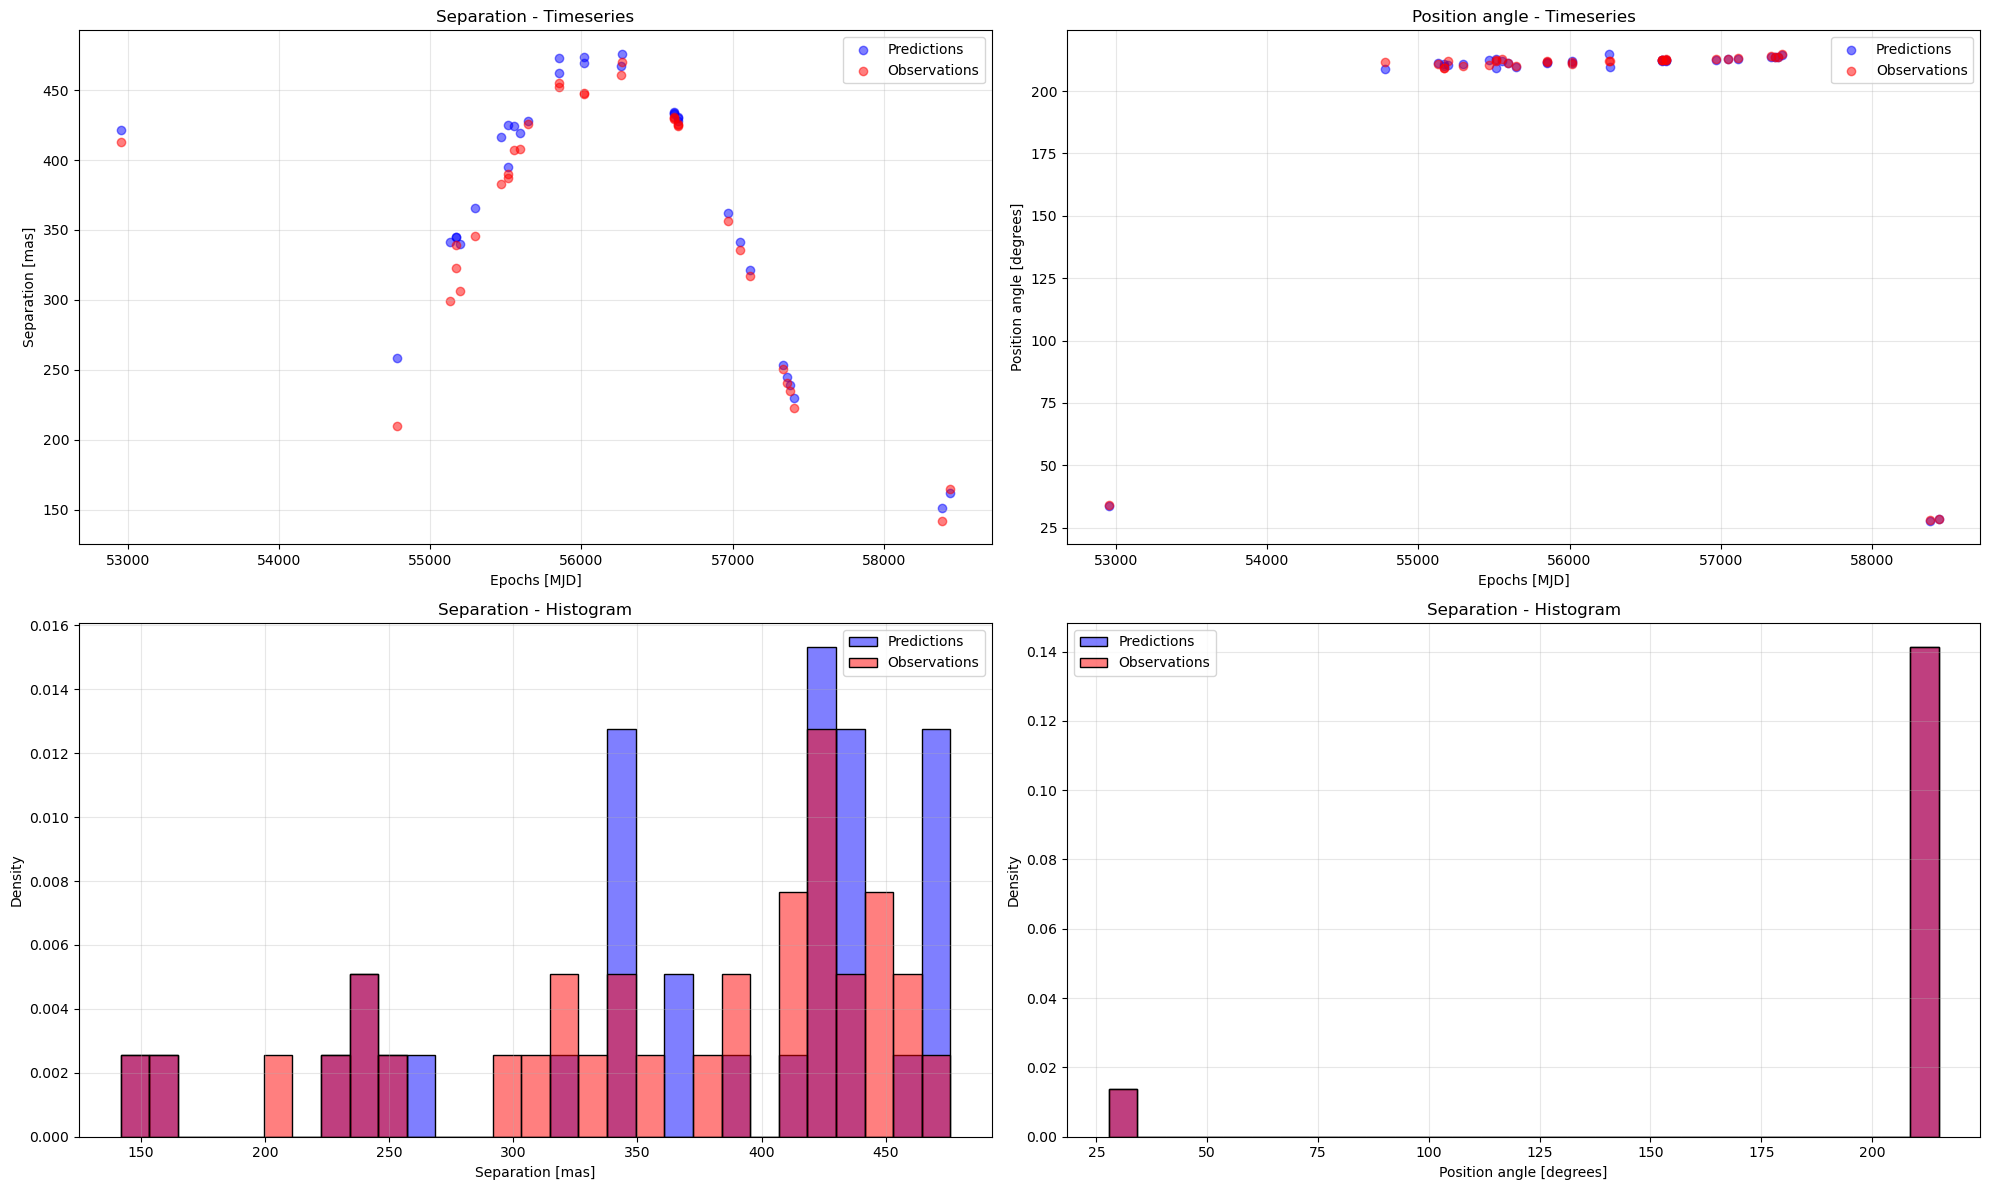

In [15]:
theta_true=[sma, ecc, inc, aop, pan, tau, plx, mtot]

prior_predictive_check(df, theta_true)

### Prior predictive checks

We will see here that the defined priors work good enough but with a huge precision to make. Our priors are relatively uninformative. For this reason, a large smaple of different value can be fed into our orbit computation. Even a slight variation of parameter can give rise to a totally different orbit. Because we "fixed" the semi major axis, we restrained the separation to the good range of values as a huge sma would give rise to larger orbits (so larger sep) and longer orbits (so longer periodicity). Even a small variation of tau would make the whole orbit shift in time.\
\
For these reasons we show here that the outputed timeseries look well enough as an orbit and are confined to the good range of values, however, they can be significantly different from the observation. This does not mean that the priors are wrongly defined.\
\
Some random generation are given bellow as example.

Similar orbit to the one given for this exercice:

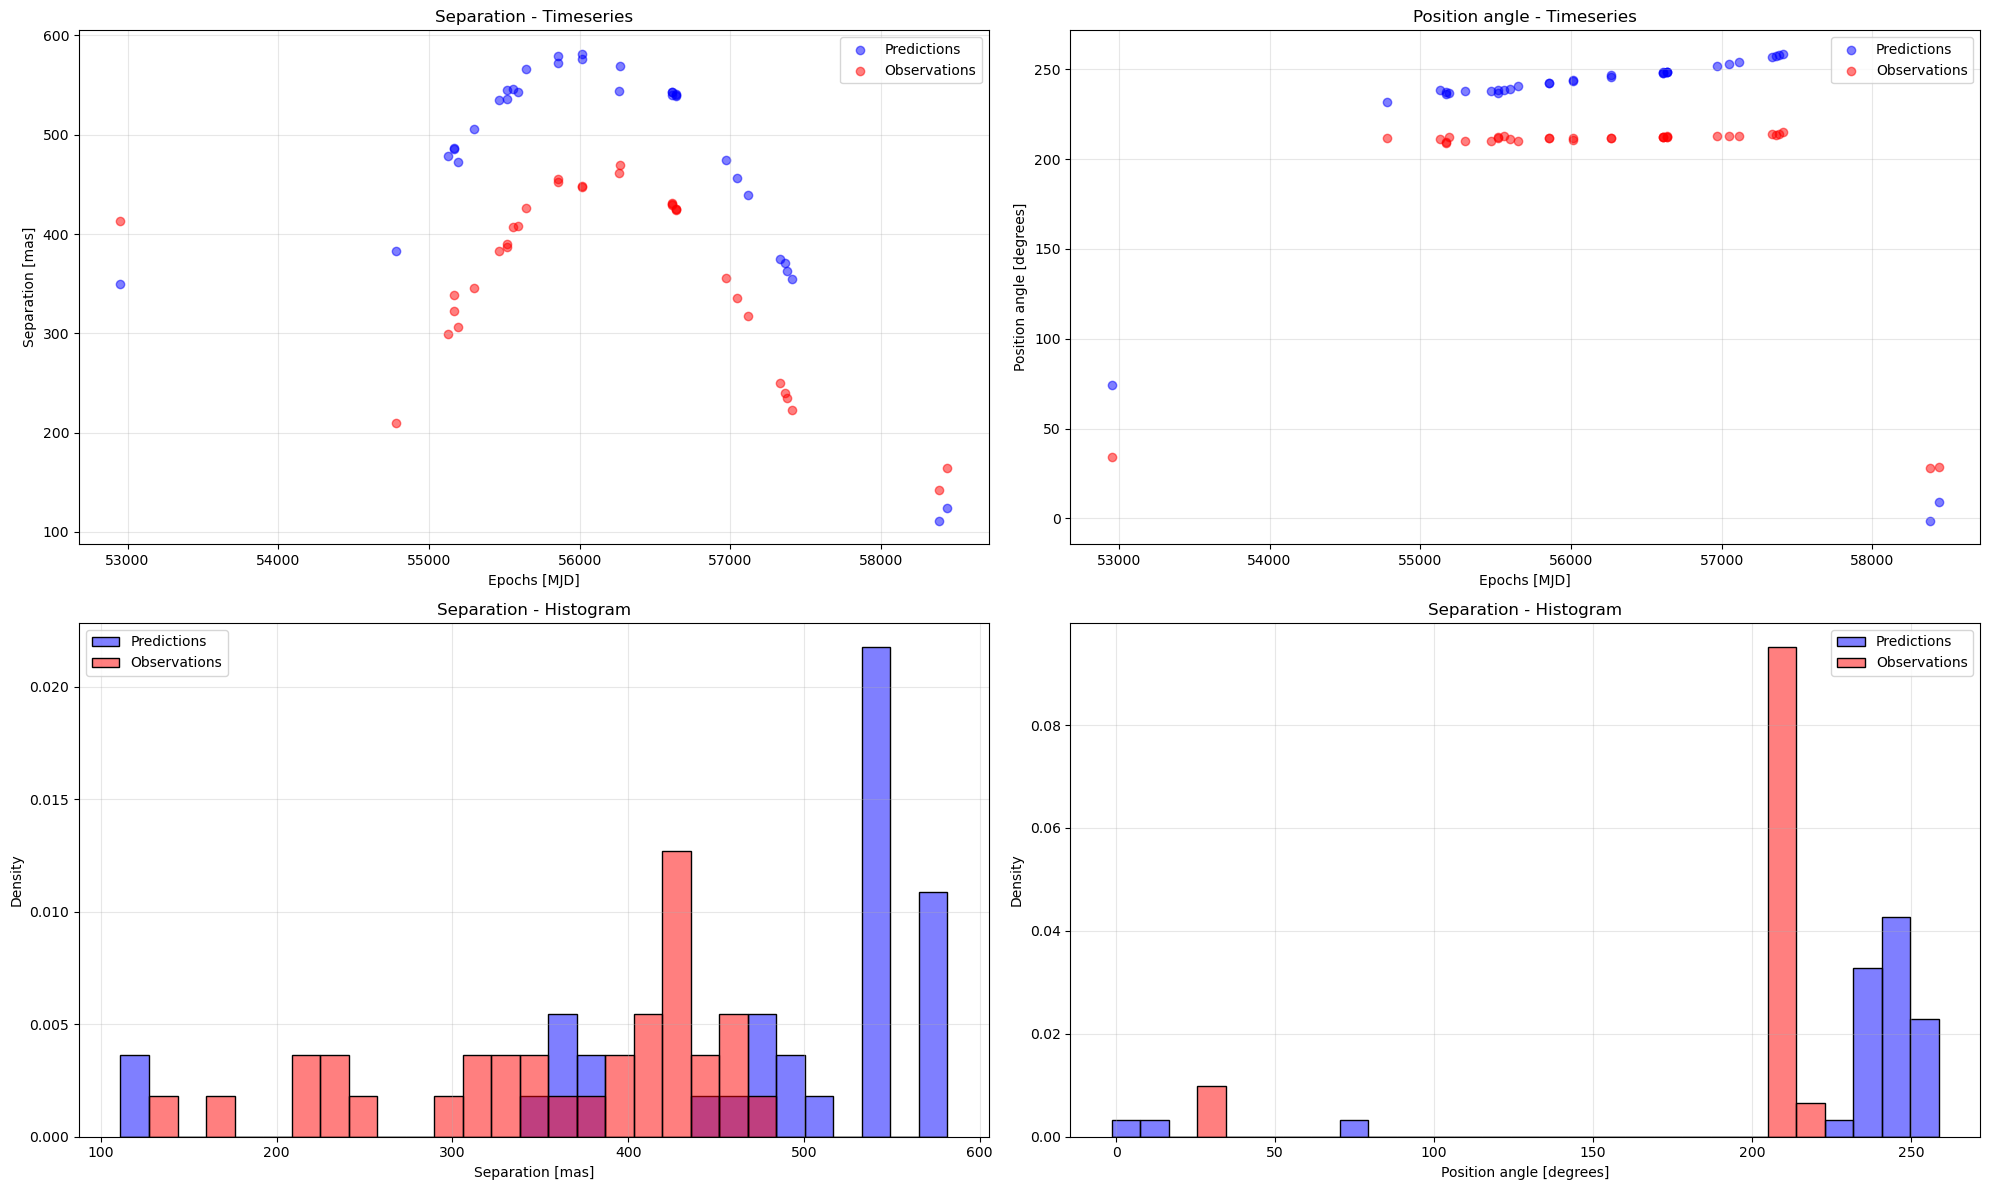

In [114]:
theta = sample_prior()
prior_predictive_check(df, theta)

In this case we have a longer orbit with completely different position angle:

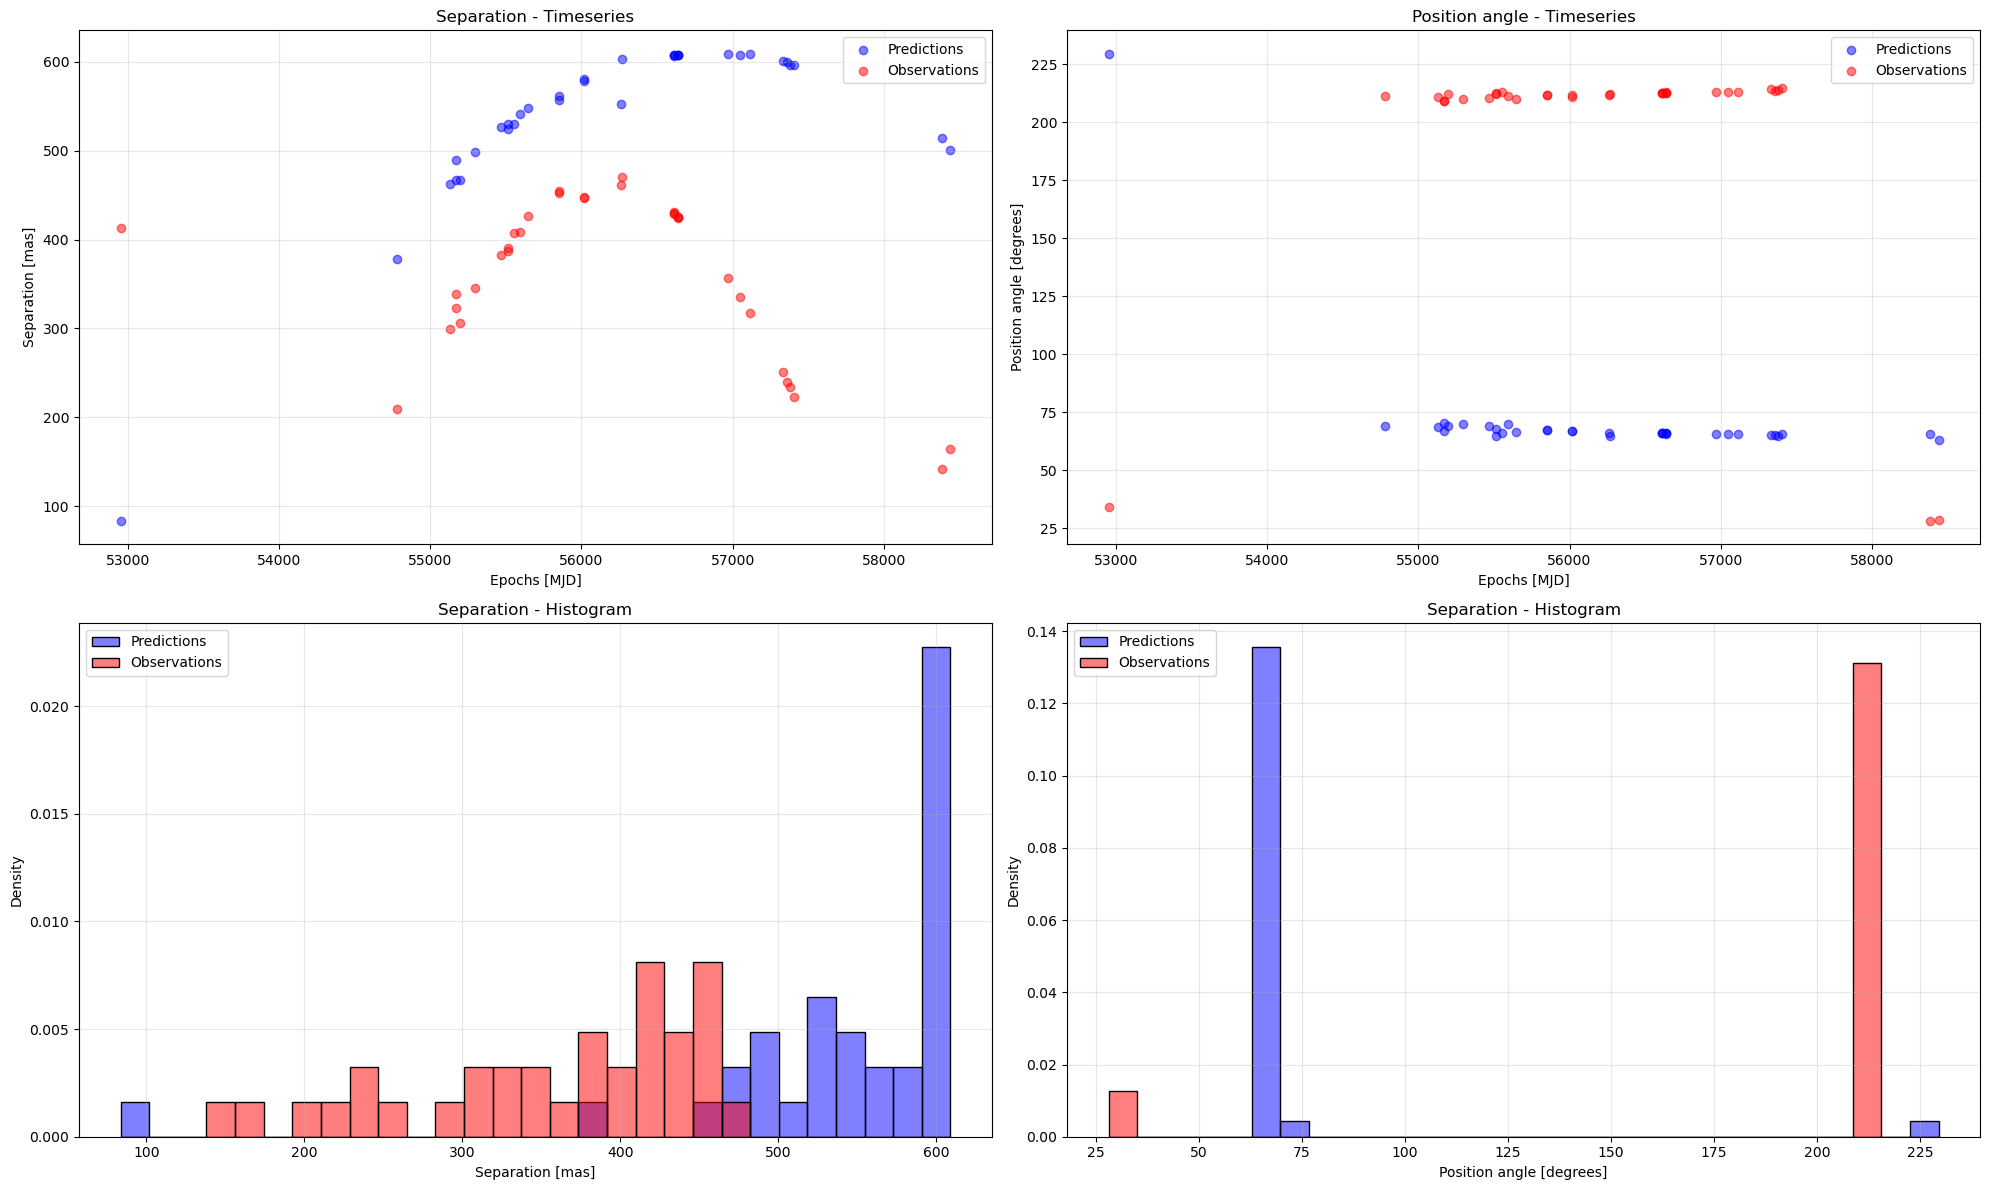

In [111]:
theta_tricky = sample_prior()
prior_predictive_check(df, theta_tricky)

### Likelihood

In [18]:
def log_prior(theta):
    """
    log prior function used for bayesian inference

    Parameters:
    -----------
        - theta: Contain the different orbital parameters (sma, ecc, inc, aop, pan, tau, plx, mtot)

    Return:
    -------
        - logprior: Value of the log prior. -inf if a parameter does not lie in the prior distribution and a finite value otherwise.
    """

    sma, ecc, inc, aop, pan, tau, plx, mtot = theta

    logp = 0

    # Semi-major axis
    if sma>0:
        logp += norm.logpdf(sma, 10.03, 5)
    else:
        return -np.inf

    # Eccentricity
    if 0<=ecc<=0.3:
        logp += uniform.logpdf(ecc, 10**(-6), 0.99)
    else:
        return -np.inf
    
    # Inclination
    if 0<=inc<=np.pi:
        logp += uniform.logpdf(inc, 0, np.pi)
    else:
        return -np.inf
    
    # Argument of periastron
    if 0<=aop<=2*np.pi:
        logp += uniform.logpdf(aop, 0, 2*np.pi)
    else:
        return -np.inf
    
    # Positio angle of nodes
    if 0<=pan<=2*np.pi:
        logp += uniform.logpdf(pan, 0, 2*np.pi)
    else: 
        return -np.inf
    
    # Epoch of periastron passage
    if 0<=tau<=1:
        logp += uniform.logpdf(tau, 0, 1)
    else: 
        return -np.inf
    
    # Parallax
    logp += norm.logpdf(plx, loc=51.44, scale=0.12)

    # Total mass
    if mtot > 0:
        logp += norm.logpdf(mtot, loc=1.75, scale=0.5)
    else:
        return -np.inf

    return logp

For the log likelihood, the function experiences sometimes error. This is mainly due to the walker exploring an area of the space that give rise to problem during the computation (_e.g. negative eccentricity or mass, negative value in a sqrt ...).\
\
A solution would have been to place a condition on the value of the parameter. However, this is already done through log prior and because the two function are calle dat the same time, we did not want to do a double check that would have rendered log prior obsolete (because the check on the parameter from the prior distribution would have also been in log_likelihood).\
\
To counteract that, we siply put a verification in the log_likelihood function. If the orbital computation indeed crashes (E not converging or simply orbit crashing) it would output a RuntimeError. When that is the case, because it is due to the wrong value of the parameter by a walker, we just output -inf instead of the error. This assure that the log posterior will be -inf and the values of the parameters considered "innacurate".

In [19]:
def log_likelihood(theta, observations):
    """
    log likelihood function used for bayesian inference

    Parameters:
    -----------
        - theta: Contain the different orbital parameters (sma, ecc, inc, aop, pan, tau, plx, mtot)
        - observation: pandas.Dataframe containing the values real values of the observation (sep, pa)

    Returns:
    --------
        - log_like_tot: log likelihood summed on the different epochs
    """
    try:
        sma, ecc, inc, aop, pan, tau, plx, mtot = theta
        sep_pred, pa_pred = compute_orbit(observations["epoch"], sma, ecc, inc, aop, pan, tau, plx, mtot)

        log_like_sep = norm.logpdf(observations["sep"], loc=sep_pred, scale=observations["sep_err"])
        log_like_pa = norm.logpdf(observations["pa"], loc=pa_pred, scale=observations["pa_err"])

        log_like_tot = np.sum(log_like_sep + log_like_pa)

        return log_like_tot
    
    except RuntimeError:
        # Security when a walker explore an area where value would make the orbital computation crash
        return -np.inf



In [20]:
def log_posterior(theta, observations):
    """
    log posterior function used for bayesian inference

    Parameters:
    -----------
        - theta: Contain the different orbital parameters (sma, ecc, inc, aop, pan, tau, plx, mtot)
        - observation: pandas.Dataframe containing the values real values of the observation (sep, pa)
    
    Returns:
    --------
        - log_posterior: sum of the log prior and log likelihood
    """

    return log_prior(theta) + log_likelihood(theta, observations)

In [19]:
theta_test = sample_prior()

lp = log_prior(theta_test)
ll = log_likelihood(theta_test, df)
post = log_posterior(theta_test, df)

print(lp, ll, post)

-7.142474069352256 -411534.41785397957 -411541.56032804894


<div class="alert alert-success">
    
**Q5**. Draw the probabilistic graphical model. What are the observed variables? What are the latent variables? What are the hyperparameters?
    
</div>

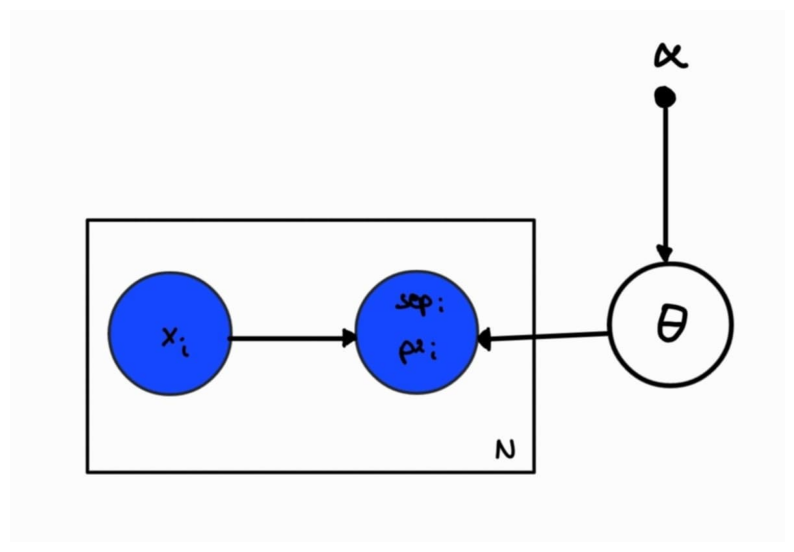

In [7]:
from PIL import Image

path = 'PGM.jpg'

image = Image.open(path)

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('off')
plt.show()

- $\alpha$ (_Hyperparameter_): Contain the boundaries and information for the distribution of the orbital parameters
- $\theta$ (_Latent variable_): Orbital parameters. It is not observed it the case of this work and are what we try to predict by inference.
- $x_i$ (_Observable variable_): Contain the observation of the noise and value of the epochs. The plate (N) assure that there is an output value for each eopchs (1 to N)
- $sep_i$ and $pa_i$ (_Observable variable_): The result of the whole computation ith the orbital parameters and for each epoch.

# Compute

You are given the dataset `beta_pic_b_sep_pa.csv`, which contains astrometric measurements of Beta Pictoris b at different epochs. Each row in the dataset corresponds to an observation and includes the following columns:
- `epoch`: the time $t$ of observation (in Modified Julian Date, MJD)
- `sep_obs`: measured separation [mas]
- `sep_err`: uncertainty in the measured separation [mas]
- `pa_obs`: measured position angle [degrees]
- `pa_err`: uncertainty in the measured position angle [degrees]

<div class="alert alert-success">
    
**Q6**. Use MCMC (via `emcee`) to sample from the posterior distribution of the orbital parameters.
- Assess and discuss autocorrelation, mixing, and convergence of the chains.
- Visualize the posterior distributions and compare them with the prior distributions.
    
</div>

In [25]:
ndim = 8
nwalkers = ndim * 4

pos_lit = np.array([10, 0.10, np.deg2rad(88.9), np.deg2rad(212.5), np.deg2rad(31.77), 0.78, 51.44, 1.75])
#scales = np.array([0.5, 0.001, np.deg2rad(2.5), np.deg2rad(5), np.deg2rad(5), 0.05, 0.12, 0.5])
scales = 0.05

theta0 = pos_lit + scales * np.random.randn(nwalkers, ndim)


In [26]:
np.deg2rad(31.77)

np.float64(0.5544911033585985)

In [27]:
theta0[:,1] = abs(theta0[:,1])
theta0[:,1]

array([0.09805182, 0.06331796, 0.10594138, 0.13235582, 0.16274975,
       0.07093339, 0.11752331, 0.05127789, 0.06506324, 0.16261833,
       0.13319597, 0.13607853, 0.11557971, 0.17744297, 0.13413741,
       0.11724814, 0.07112845, 0.21210404, 0.15893358, 0.09253652,
       0.06089719, 0.12049078, 0.08169451, 0.12176751, 0.07747208,
       0.06160717, 0.00664609, 0.10472416, 0.19161954, 0.10158694,
       0.16922174, 0.18106353])

In [28]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(df,))


In [29]:
sampler.run_mcmc(theta0, 200000, progress=True)


100%|██████████| 200000/200000 [46:02<00:00, 72.39it/s] 


State([[1.15186692e+01 2.32134368e-01 1.54786066e+00 3.43910949e+00
  5.57574461e-01 6.15270834e-01 5.15000819e+01 1.79352899e+00]
 [1.02205004e+01 1.30332963e-01 1.55092618e+00 3.49448900e+00
  5.59824349e-01 7.35648899e-01 5.14985441e+01 1.76781200e+00]
 [1.01738651e+01 1.19986379e-01 1.55074115e+00 3.42400165e+00
  5.59175261e-01 7.35613347e-01 5.15233800e+01 1.79286575e+00]
 [9.26246829e+00 2.43848348e-02 1.55194491e+00 3.39953499e+00
  5.59430512e-01 8.38249103e-01 5.13314687e+01 1.78872713e+00]
 [1.12093913e+01 2.11036629e-01 1.55289231e+00 3.51774640e+00
  5.61734174e-01 6.42218864e-01 5.14840510e+01 1.75321272e+00]
 [1.01964925e+01 1.23449028e-01 1.55149537e+00 3.43748103e+00
  5.59922892e-01 7.36450461e-01 5.14120454e+01 1.79699729e+00]
 [9.63681274e+00 7.33527761e-02 1.54593331e+00 3.50975270e+00
  5.56217141e-01 8.02814942e-01 5.15456177e+01 1.76363527e+00]
 [1.03317901e+01 1.26255407e-01 1.55098654e+00 3.33433285e+00
  5.58997295e-01 7.16035189e-01 5.13263954e+01 1.84372790

In [30]:
# Save
with open("sampler.pkl", "wb") as f:
    pickle.dump(sampler, f)

In [21]:
# Load
with open("sampler.pkl", "rb") as f:
    sampler = pickle.load(f)

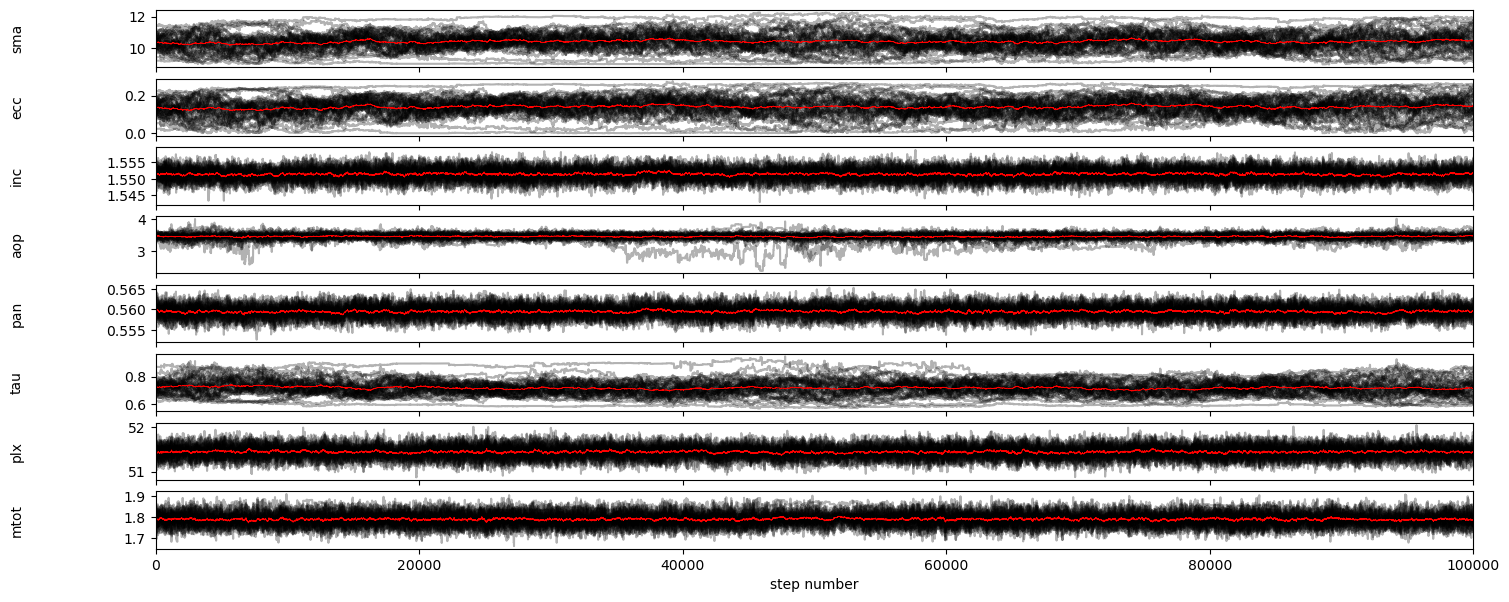

In [23]:
ndim = 8

fig, axes = plt.subplots(ndim, figsize=(17, 7), sharex=True)
samples = sampler.get_chain(discard=100000)
labels = ["sma", "ecc", "inc", "aop", "pan", "tau", "plx", "mtot"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)

    mean_per_step = np.mean(samples[:,:,i], axis=1)
    ax.plot(mean_per_step, color="r", linewidth=0.5)

    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.show()

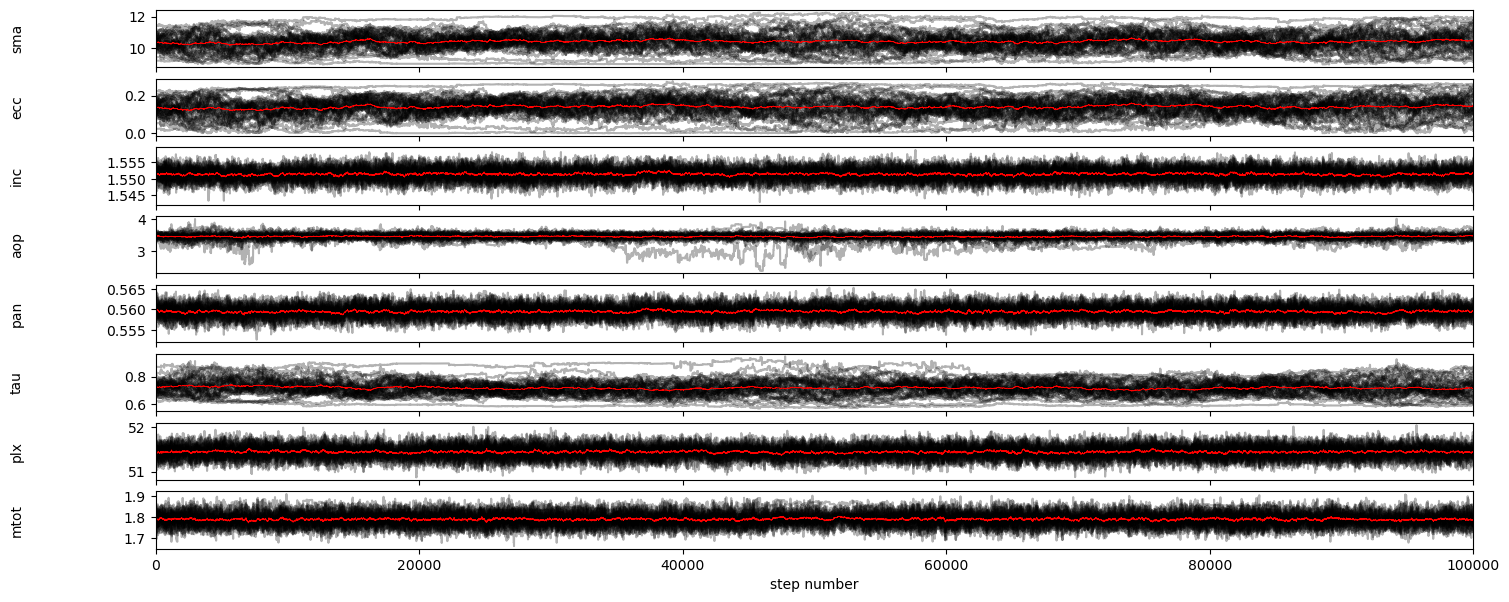

In [220]:
fig, axes = plt.subplots(ndim, figsize=(17, 7), sharex=True)
samples = sampler.get_chain(discard=100000)
labels = ["sma", "ecc", "inc", "aop", "pan", "tau", "plx", "mtot"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)

    mean_per_step = np.mean(samples[:,:,i], axis=1)
    ax.plot(mean_per_step, color="r", linewidth=0.5)

    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.show()

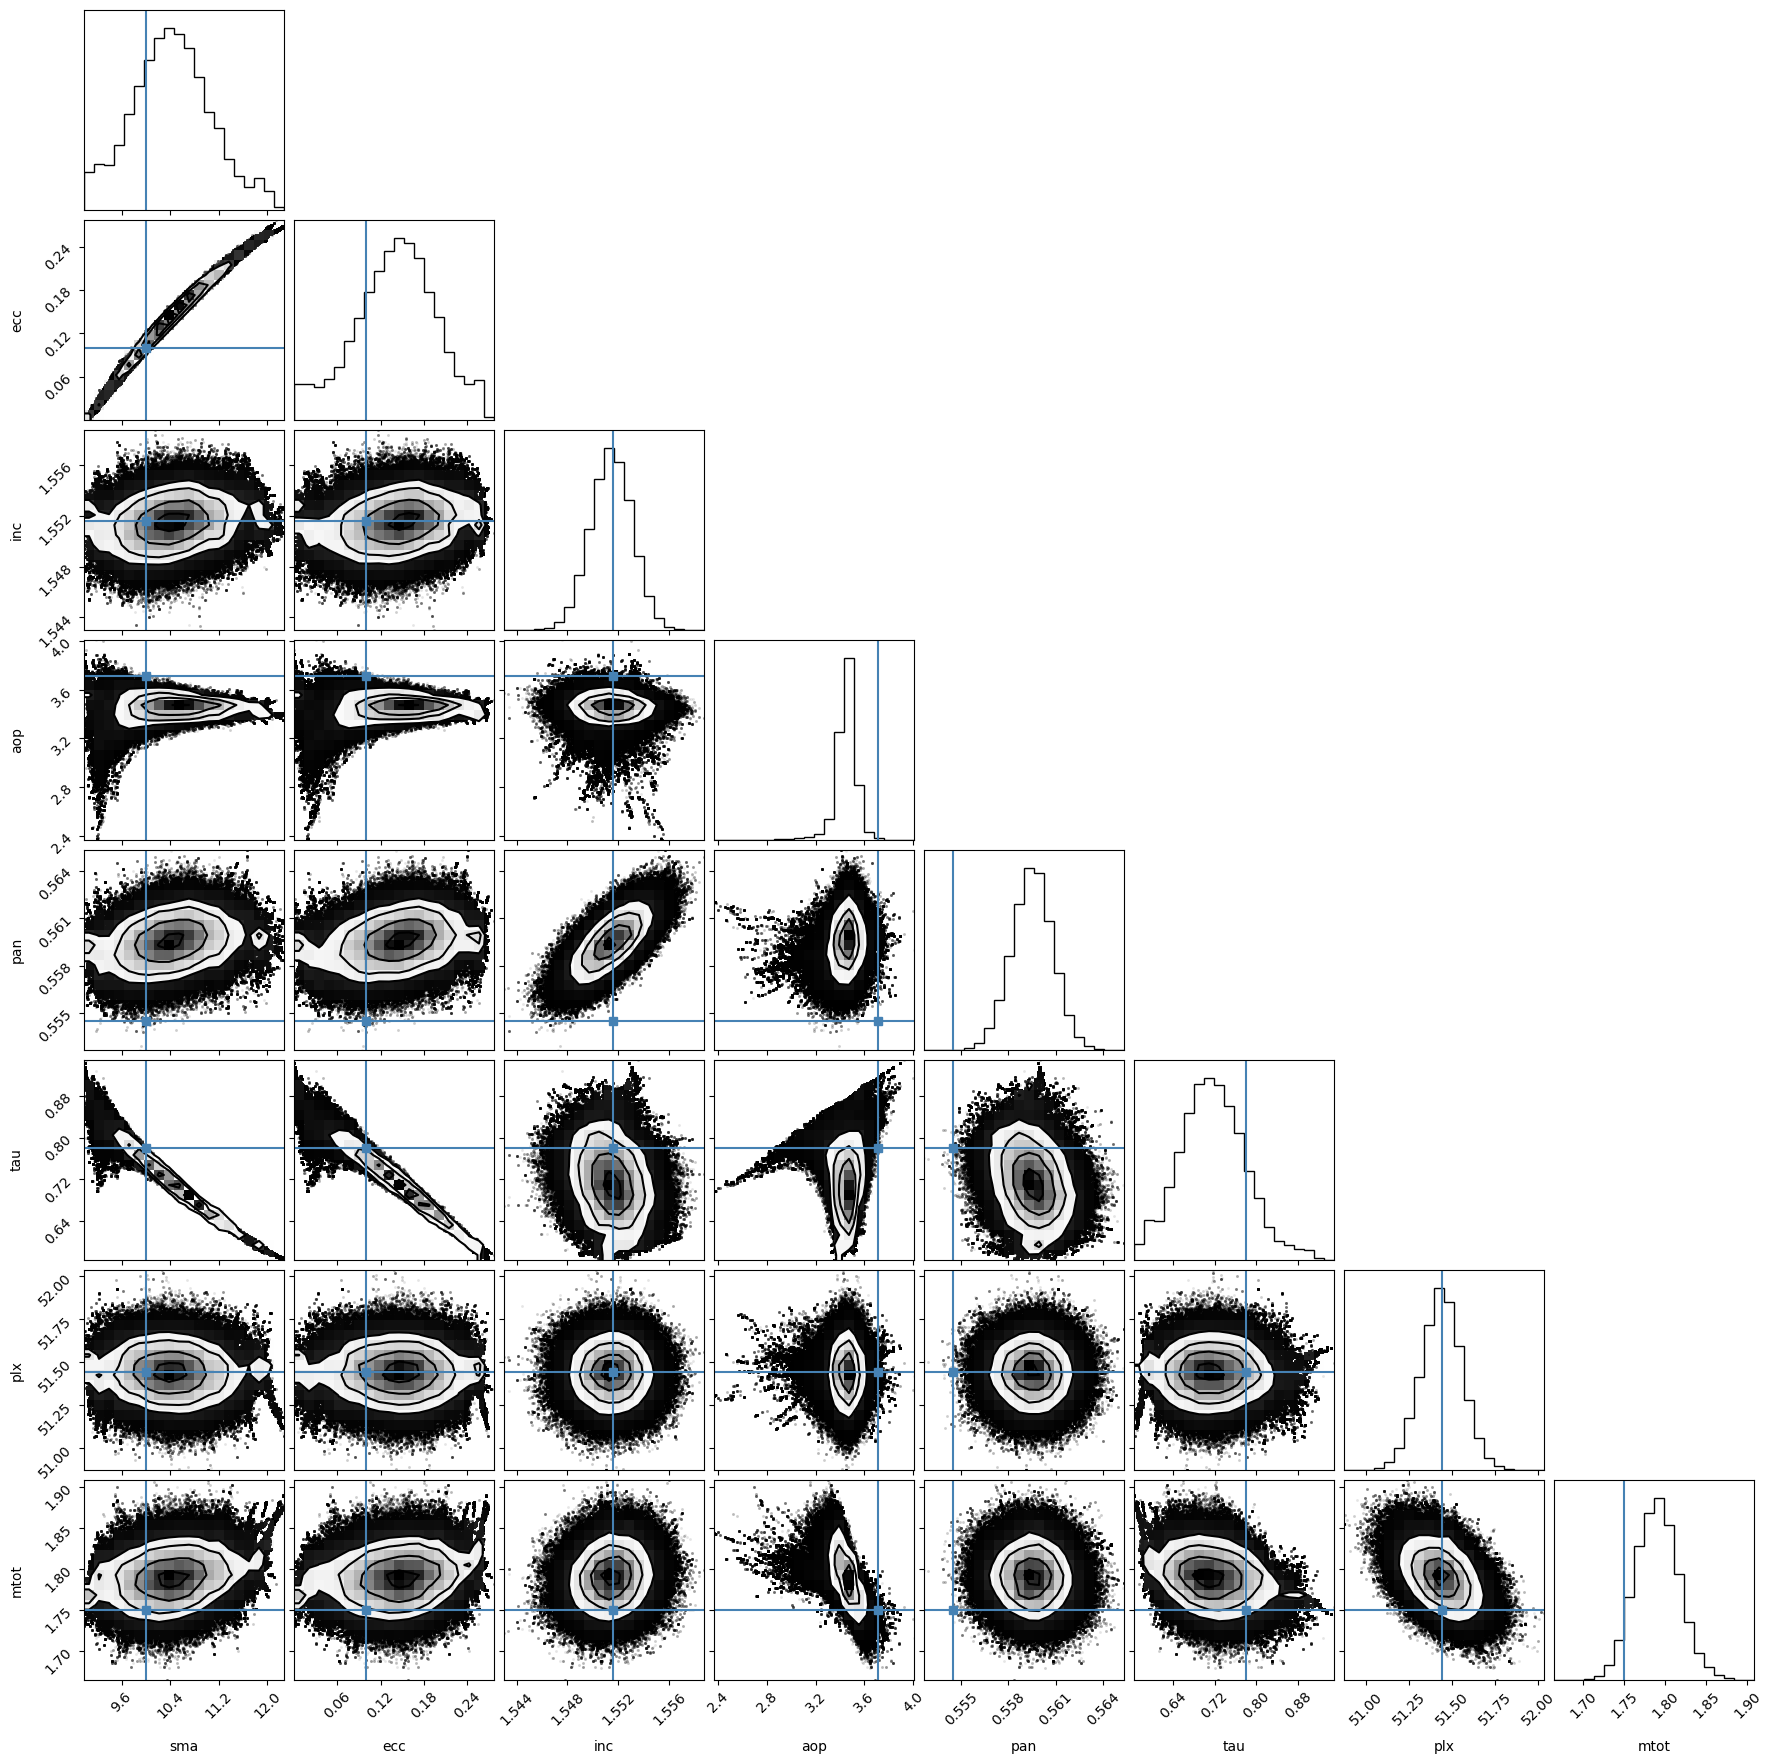

In [25]:
pos_lit = np.array([10, 0.10, np.deg2rad(88.9), np.deg2rad(212.5), np.deg2rad(31.77), 0.78, 51.44, 1.75])
thetas = sampler.get_chain(flat=True,discard=100000)
fig = corner.corner(thetas, labels=labels, truths=pos_lit)

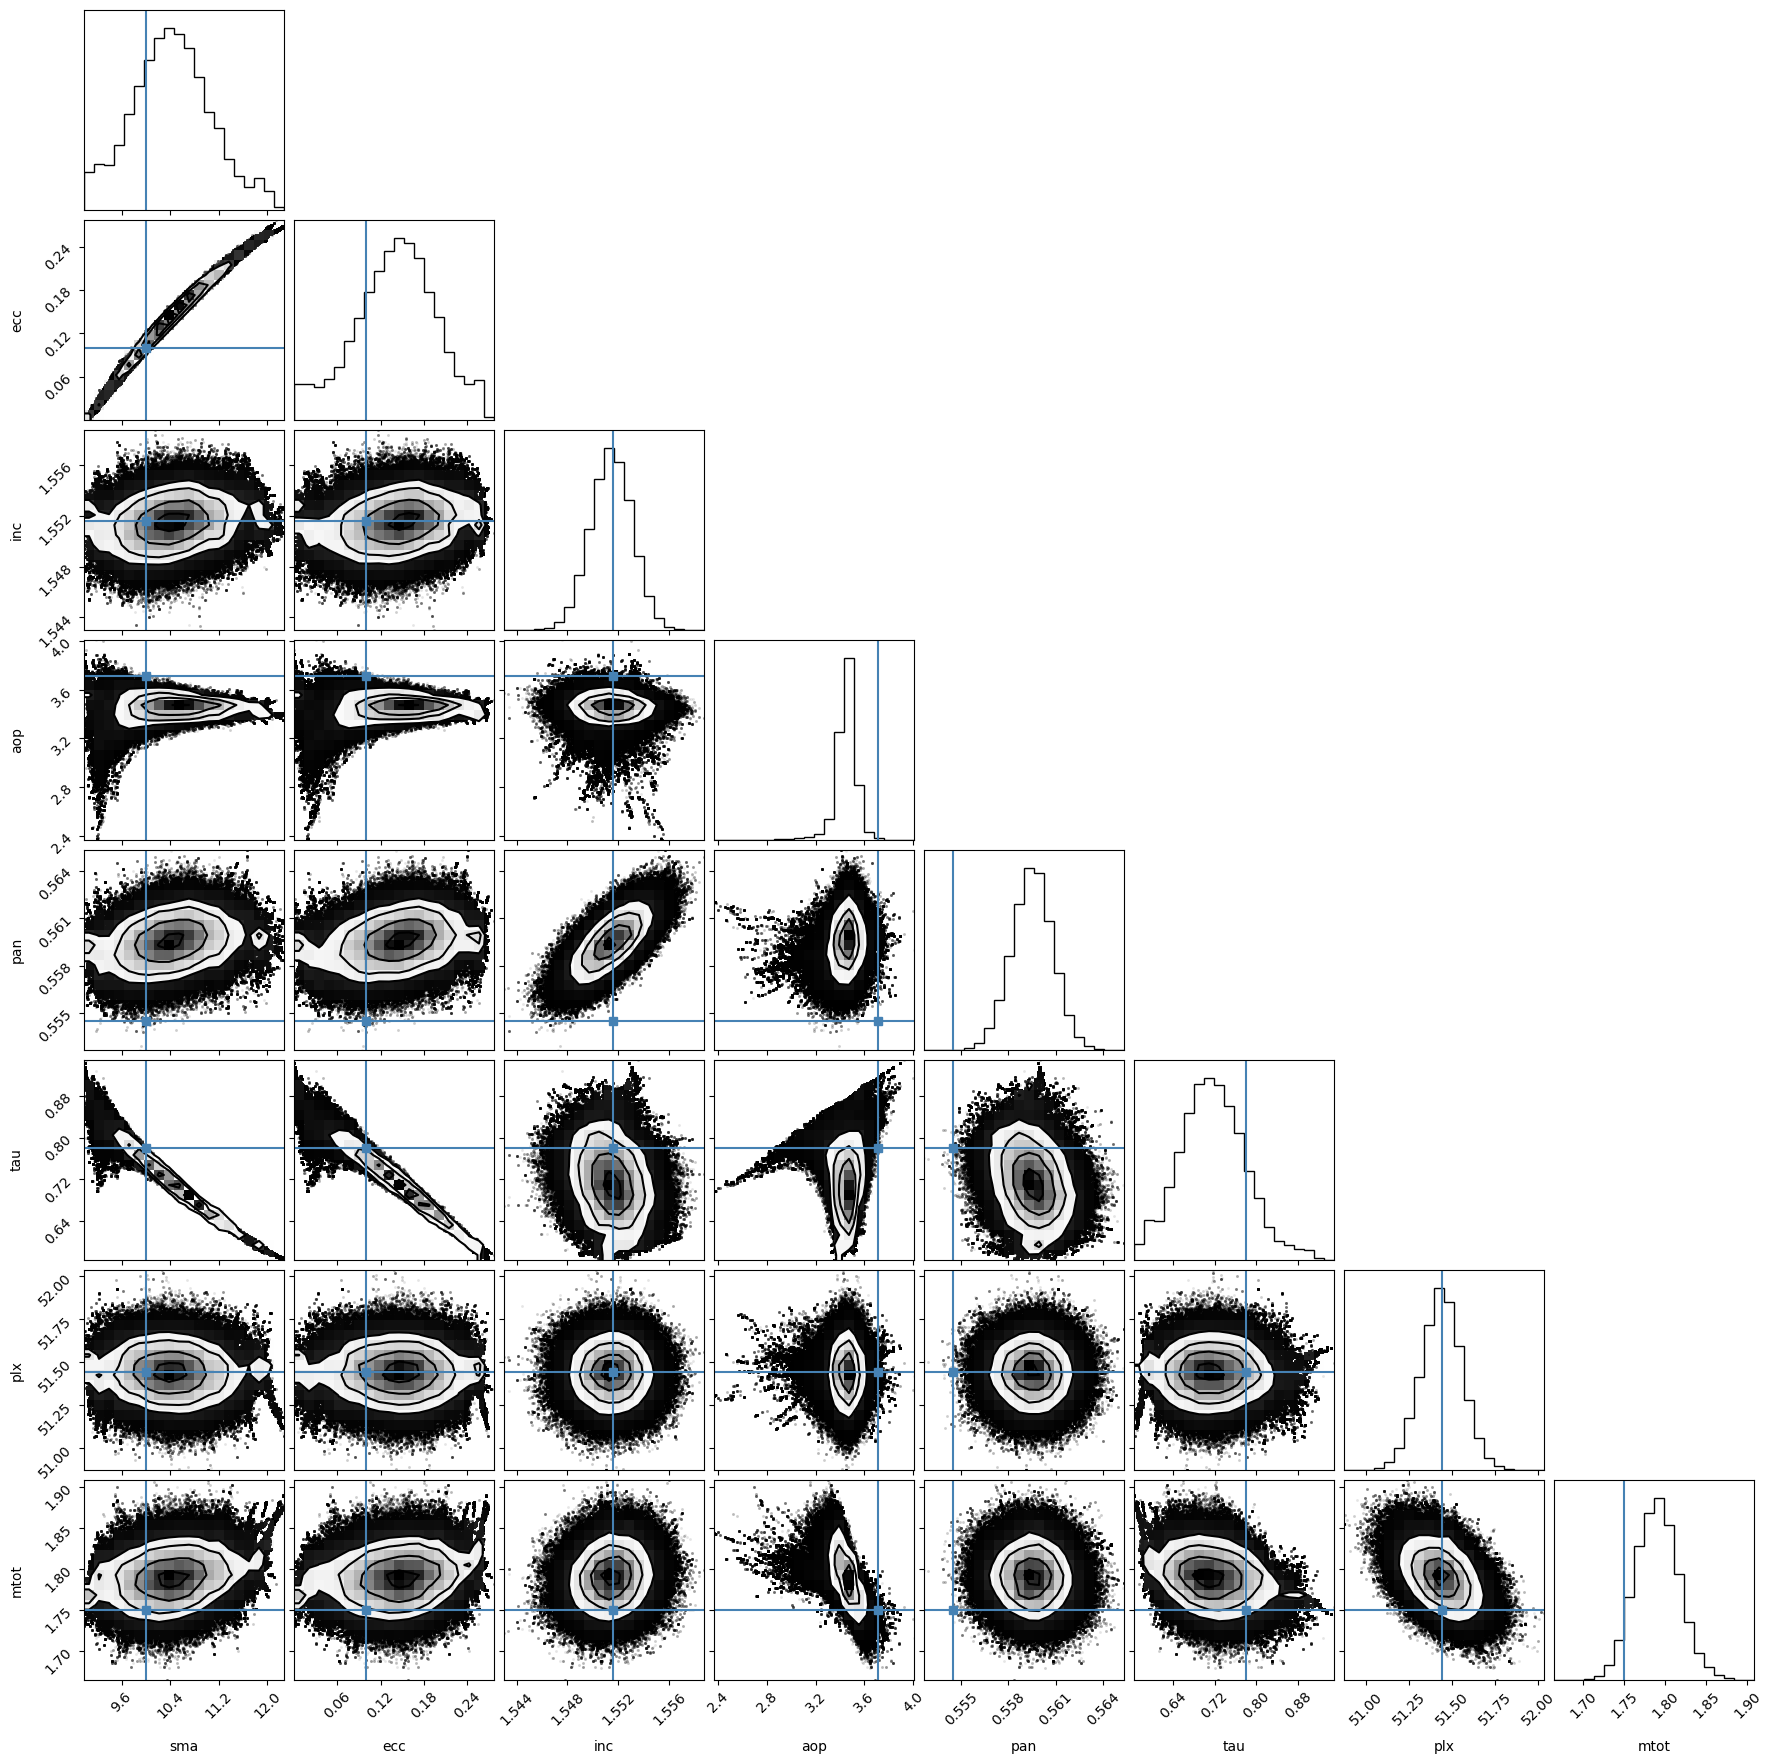

In [221]:
thetas = sampler.get_chain(flat=True,discard=100000)
fig = corner.corner(thetas, labels=labels, truths=pos_lit)


In [222]:
tau_autocorr = sampler.get_autocorr_time(quiet=True)
labels = ["sma", "ecc", "inc", "aop", "pan", "tau", "plx", "mtot"]

The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 4000;
tau: [8767.36546568 8805.1296127  1056.6678993  2191.16408254 1003.59214658
 8611.13977768  762.92891814 1167.51151711]


In [228]:
for i, (label, tau) in enumerate(zip(labels, tau_autocorr)):
    ratio = 100000 / tau
    status = "Good" if ratio > 50 else "Problem"
    print(f"{status} {label:5s}: tau={tau:6.1f}, n/tau={ratio:6.1f}")

Problem sma  : tau=8767.4, n/tau=  11.4
Problem ecc  : tau=8805.1, n/tau=  11.4
Good inc  : tau=1056.7, n/tau=  94.6
Problem aop  : tau=2191.2, n/tau=  45.6
Good pan  : tau=1003.6, n/tau=  99.6
Problem tau  : tau=8611.1, n/tau=  11.6
Good plx  : tau= 762.9, n/tau= 131.1
Good mtot : tau=1167.5, n/tau=  85.7


### Discussion

- __sma__: \
The chain does not seem to have a high autocorrelation as walkers do not seem packed and explore well the space indicating also a good mixing. However, it has a high autocorrelation time indicating that the walkers explore slowly the space. Because of this high time, we could say that the chain has not converged; However I tried to run longer chains (until I ran out of ram) and the problem did not disappeared which good indicate a potential problem with the priors or the initialization.

- __ecc__: \
The same conclusion can be said for the eccentricity than for the sma. The only good thing is that, probably thanks to the initialization, the posterior is centered around the good value (from the litterature). Again, the same discussion about convergence can be said, however, as we go from an initial uniform distribution and end up with a normal distribution centered around the good value, it can be seen as an improvement (eventhough it is not totally trustworthy).

- __inc__:\
The inclination has another problem. The autocorrelation time is low enough and we see that the walkers seem independent enough. However, we here have a problem of mixing as the walkers are stuck in that precise area of the space. We can still assume convergence eventhough it might be influenced by the poor mixing.

- __aop__:\
The aop also has a higher autocorrelation time than other chains (not to the point f sma and ecc). The mixing is not too bad as we see it explore the space. We can assume convergence but around a value different than the litterature.

- __pan__:\
Same conclusion can be said for pan than for the inclination. It does not seem to explore well the space and seem stuck. It can be thanks to the initialization (around the litterature value) but it maybe influenced too much.

- __tau__:\
Same conclusion can be said for tau than sma and ecc. High autocorrelation time but good mixing. Convergence could be assumed as it is centered around the supposed accurate value.

- __plx__:\
Looks really good. Low autocorrelation as we see that it explores well the space independently. Good mixing. Converged around the accurate value.

- __mtot__:\
Same conclusion than for plx.


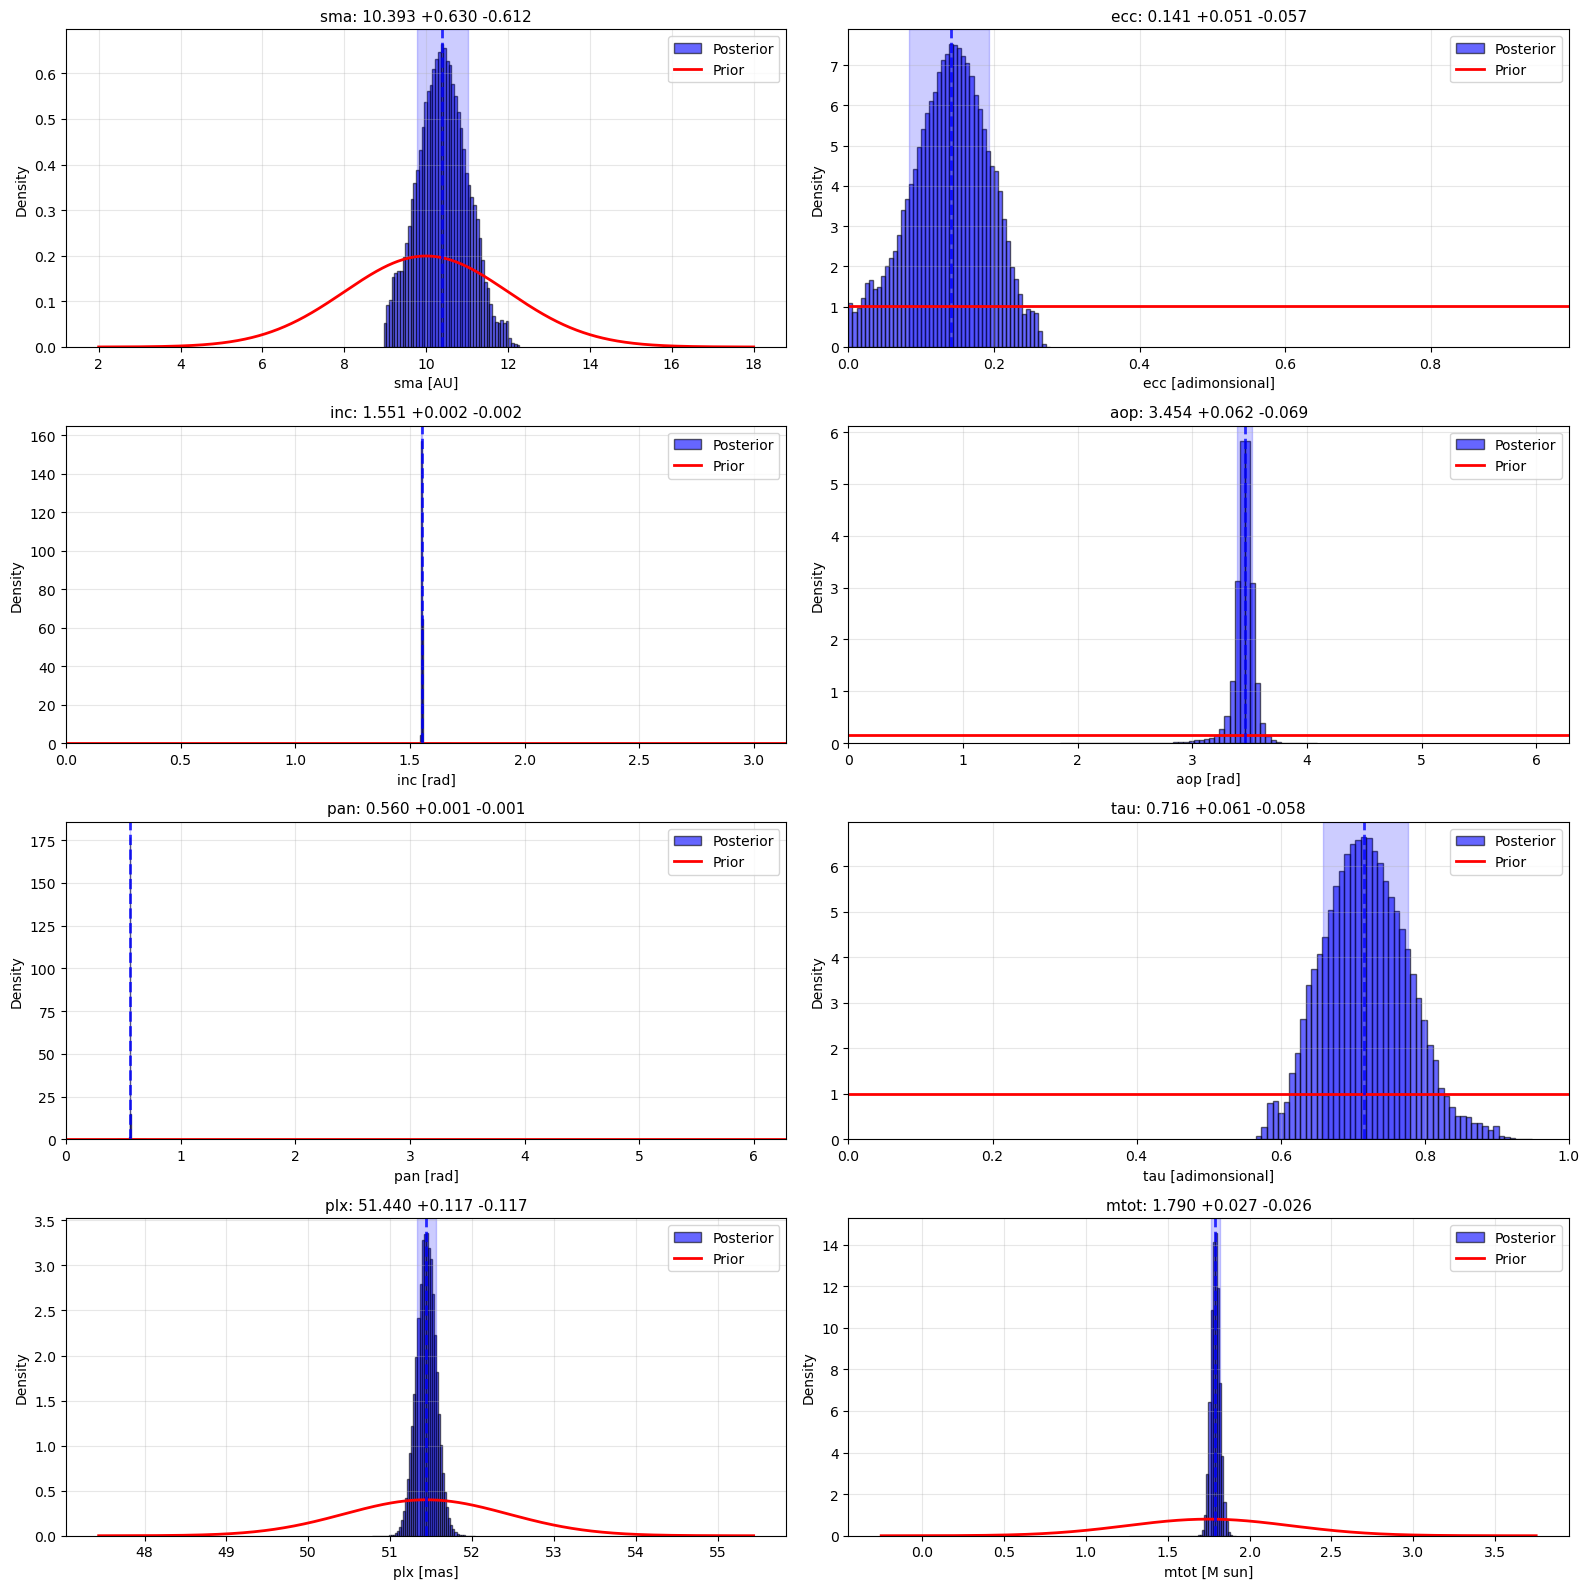

In [236]:
# Priors
prior_params = {
    'sma': ('normal', 10.0, 2.0),
    'ecc': ('uniform', 0, 0.99), 
    'inc': ('uniform', 0, np.pi),
    'aop': ('uniform', 0, 2*np.pi),
    'pan': ('uniform', 0, 2*np.pi),
    'tau': ('uniform', 0, 1),
    'plx': ('normal', 51.44, 1.0),
    'mtot': ('normal', 1.75, 0.5)
}

labels = ["sma", "ecc", "inc", "aop", "pan", "tau", "plx", "mtot"]
units = ["AU", "adimonsional", "rad", "rad", "rad", "adimonsional", "mas", "M sun"]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, (ax, label, unit) in enumerate(zip(axes, labels, units)):
    # Posterio (histogram)
    ax.hist(samples[:, i], bins=50, density=True, alpha=0.6, 
            color='blue', label='Posterior', edgecolor='black')
    
    # Prior (red curve)
    prior_type, *prior_vals = prior_params[label]
    
    if prior_type == 'normal':
        mean, std = prior_vals
        x = np.linspace(mean - 4*std, mean + 4*std, 1000)
        prior_pdf = norm.pdf(x, mean, std)
        ax.plot(x, prior_pdf, 'r-', linewidth=2, label='Prior')
    
    elif prior_type == 'uniform':
        a, b = prior_vals
        x = np.linspace(a, b, 1000)
        prior_pdf = uniform.pdf(x, a, b - a)
        ax.plot(x, prior_pdf, 'r-', linewidth=2, label='Prior')
        ax.set_xlim(a, b)
    
    # median and percentile of the posterior
    median = np.percentile(samples[:, i], 50)
    lower = np.percentile(samples[:, i], 16)
    upper = np.percentile(samples[:, i], 84)
    
    ax.axvline(median, color='blue', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvspan(lower, upper, alpha=0.2, color='blue')
    
    ax.set_xlabel(f'{label} [{unit}]',)
    ax.set_ylabel('Density')
    ax.set_title(f'{label}: {median:.3f} +{upper-median:.3f} -{median-lower:.3f}', 
                 fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- __sma__: \
Normal law just like the prior. Centered around the good value eventhough it shifted to the right a bit. It has a smaller deviation than the prior.
- __ecc__: \
This was expected for the prior. It is centered in the right place (maybe due to initialization of walkers). It is particularly interesting as the eccentricity for exoplanet systems is aroung 0.1 for multi-planet systems and 0.3 for single planet systems. The posterior distribution encompassed that really well.

- __inc__:\
As mentionned before, we see that it is stuck around a signle value eventhough it was given a uniform prior. It might be due to the initialization of the walkers. However it is centered on the right value.

- __aop__:\
As for the eccentricity, the aop has transformed a uniform prior into a normal distribution centered on the right value. It is more precise and accurate.

- __pan__:\
Same than for inc.

- __tau__:\
Tau was relatively hard to estimate when it comes to initialization and it was done by test and error. We see that the initial uniform distribution has become a normal distribution centered around a value slightly less than the supposed accurate value.

- __plx__:\
Plx is totally accurate. The posterior is a normal distribution even more strict (smaller deviation), centered around the accurate value.

- __mtot__:\
Same conclusion than for plx


<div class="alert alert-success">
    
**Q7**. Use variational inference (any variant) to approximate the posterior distribution of the orbital parameters.
- Assess the quality of the approximation.
- Visualize the variational posterior distributions and compare them with the prior distributions.
    
</div>

<div class="alert alert-success">

**Q8**. Compare and discuss MCMC and variational inference results.

</div>

# Critique: posterior predictive checks

<div class="alert alert-success">

**Q9**. Generate posterior predictive samples. Assess whether the observations fall within the posterior predictive intervals.

</div>

In [ ]:
epoch_min = df["epoch"].min()
epoch_max = df["epoch"].max()

epochs_grid = np.linspace(epoch_min, epoch_max, 1000)

In [121]:
# Fixed choice
rng = np.random.default_rng(42)
idx = rng.choice(len(thetas), size=1000, replace=False)
theta_ppc = thetas[idx]

In [122]:
sep_ppc = []
pa_ppc = []

for theta in tqdm.tqdm(theta_ppc, desc="Computation"):
    sma, ecc, inc, aop, pan, tau, plx, mtot = theta

    sep_model, pa_model = compute_orbit(epochs_grid, sma, ecc, inc, aop, pan, tau, plx, mtot)

    #sep_draw = rng.normal(loc=sep_model, scale=np.interp(epochs_grid,df["epoch"],df["sep_err"]))

    #pa_draw = rng.normal(loc=pa_model, scale=np.interp(epochs_grid,df["epoch"],df["pa_err"]))

    sep_ppc.append(sep_model)
    pa_ppc.append(pa_model)

sep_ppc = np.array(sep_ppc) 
pa_ppc = np.array(pa_ppc)


Computation: 100%|██████████| 1000/1000 [00:04<00:00, 203.41it/s]


In [ ]:
sep_q = np.percentile(sep_ppc, [5, 50, 95], axis=0)
pa_q = np.percentile(pa_ppc, [5, 50, 95], axis=0)

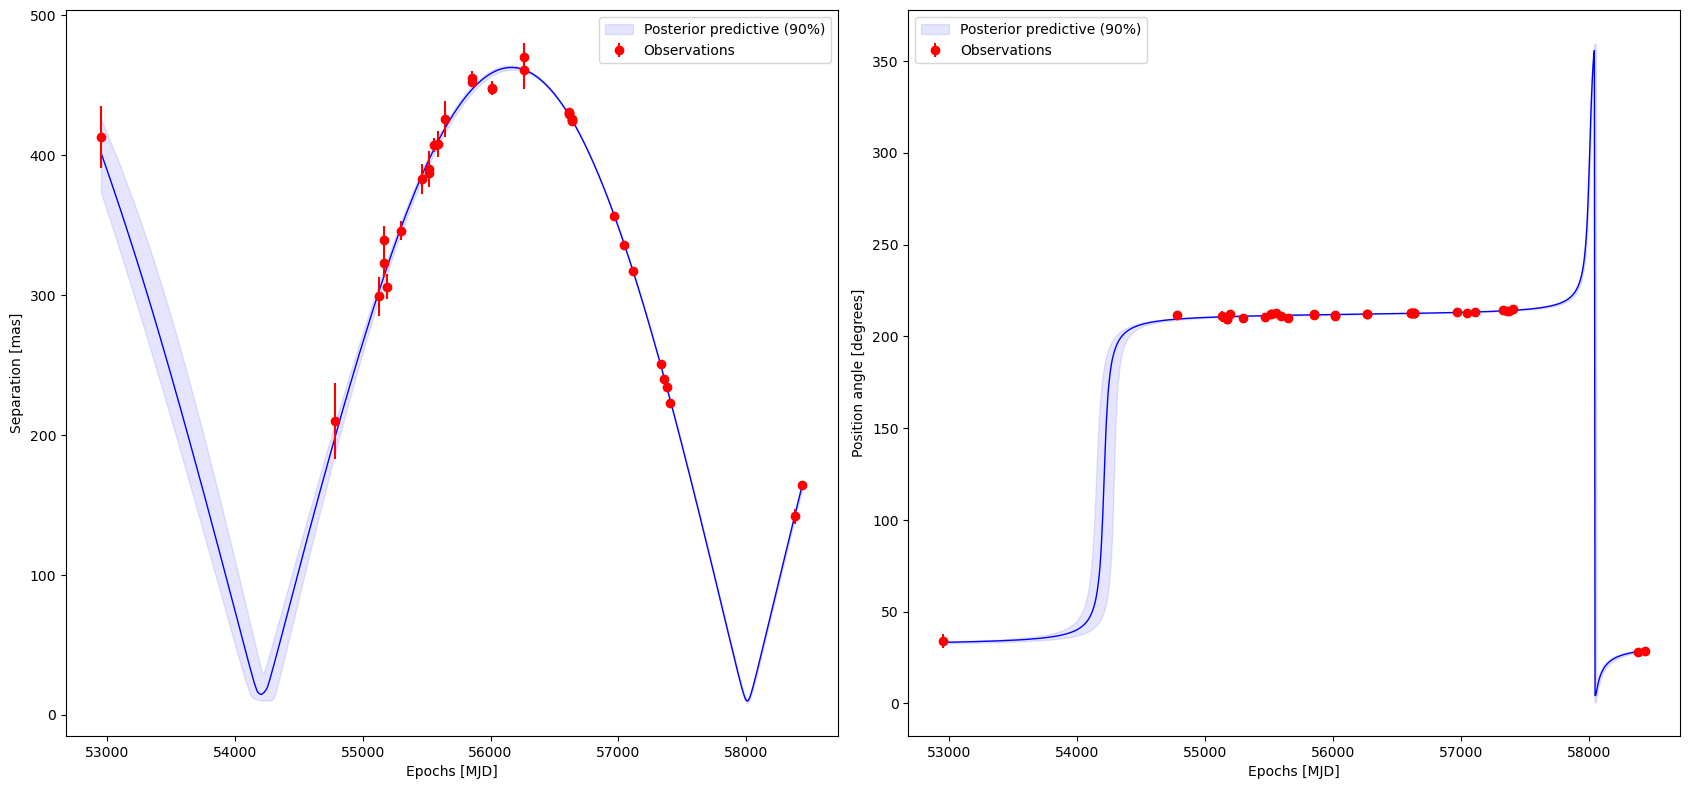

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8), sharex=True)


# SEP

ax = axes[0]

ax.fill_between(epochs_grid,sep_q[0],sep_q[2],color="b",alpha=0.1,label="Posterior predictive (90%)")

ax.plot(epochs_grid,sep_q[1],color="b",lw=1)

ax.errorbar(df["epoch"],df["sep"],yerr=df["sep_err"],fmt="o",color="red",label="Observations")

ax.set_ylabel("Separation [mas]")
ax.set_xlabel("Epochs [MJD]")
ax.legend()

# PA

ax = axes[1]

ax.fill_between(epochs_grid,pa_q[0],pa_q[2],color="b",alpha=0.1,label="Posterior predictive (90%)")

ax.plot(epochs_grid,pa_q[1],color="b",lw=1)

ax.errorbar(df["epoch"],df["pa"],yerr=df["pa_err"],fmt="o",color="red",label="Observations")

ax.set_xlabel("Epochs [MJD]")
ax.set_ylabel("Position angle [degrees]")
ax.legend()

plt.tight_layout()
plt.show()


Here, we took a lot more of epoch in order to visualize the full orbit. We can thus check the continuous orbital model and not only have information at the discrete time step of the observations. \
\
We then take 1000 thetas in the posterior distribution (from the sampler) and for each epochs (we took 500 here) we compute pa and sep for the orbit. This may, due to the lack of data in some interval, render it obsolete. However, it will just make the interval larger.

In the case of our model, we see that the observation lie really good in the interval obtained from posterior predictive checks.

<div class="alert alert-success">
    
**Q10**. Create 
- a plot showing observed positions and posterior predicted orbits around the star (i.e., $\Delta \mathrm{RA}$ vs. $\Delta \mathrm{Dec}$).
- a plot showing observed angular displacement over time, along with posterior predictive intervals (i.e., $\Delta \mathrm{RA}$ vs. $t$ and $\Delta \mathrm{Dec}$ vs. $t$).


In [57]:
df_sorted = df.sort_values(by="epoch")

In [58]:
Nplot = 100
indices = np.random.choice(thetas.shape[0], Nplot, replace=False)
theta_ppc = thetas[indices]

In [60]:
epochs_obs = df_sorted["epoch"].values

sep_ppc = []
pa_ppc = []

for theta in tqdm.tqdm(theta_ppc, desc="Posterior orbits"):
    sep_model, pa_model = compute_orbit(epochs_obs, *theta)
    sep_ppc.append(sep_model)
    pa_ppc.append(pa_model)

sep_ppc = np.array(sep_ppc)
pa_ppc  = np.array(pa_ppc)


Posterior orbits: 100%|██████████| 100/100 [00:00<00:00, 1937.78it/s]


In [63]:
pa_ppc_rad = np.deg2rad(pa_ppc)
pa_obs_rad = np.deg2rad(df_sorted["pa"])

delta_ra_ppc  = sep_ppc * np.sin(pa_ppc_rad)
delta_dec_ppc = sep_ppc * np.cos(pa_ppc_rad)

delta_ra_obs  = df_sorted["sep"] * np.sin(pa_obs_rad)
delta_dec_obs = df_sorted["sep"] * np.cos(pa_obs_rad)

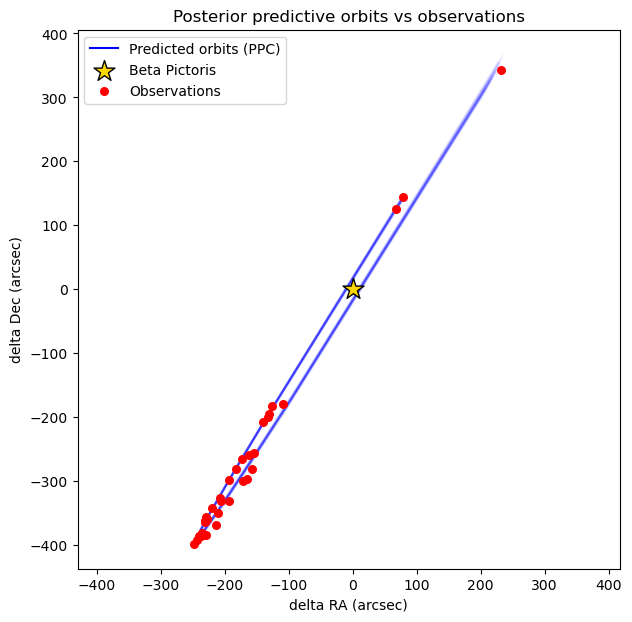

In [62]:
plt.figure(figsize=(7,7))

for i in range(Nplot):
    label = "Predicted orbits (PPC)" if i == 0 else ""
    plt.plot(delta_ra_ppc[i], delta_dec_ppc[i], color="blue", alpha=0.01, label=label)

plt.scatter(0, 0, marker='*', color='gold', s=250, label="Beta Pictoris", edgecolor='black', zorder=5)

plt.scatter(delta_ra_obs, delta_dec_obs, color="red", s=30, label="Observations", zorder=6)

plt.axis('equal')
plt.xlabel("delta RA (arcsec)")
plt.ylabel("delta Dec (arcsec)")


leg = plt.legend(loc='upper left', scatterpoints=1)
handles = getattr(leg, 'legend_handles', getattr(leg, 'legendHandles', []))

for lh in handles: 
    lh.set_alpha(1) 

plt.title("Posterior predictive orbits vs observations")
plt.show()


In [68]:
# Observations
epochs_obs = df_sorted["epoch"].values

# Posterior samples
Nppc = 2000 
indices = np.random.choice(thetas.shape[0], Nppc, replace=False)
theta_ppc = thetas[indices]

epochs_grid = epochs_obs


In [69]:
sep_ppc = []
pa_ppc  = []

for theta in tqdm.tqdm(theta_ppc, desc="Posterior predictive"):
    sep_model, pa_model = compute_orbit(epochs_grid, *theta)
    sep_ppc.append(sep_model)
    pa_ppc.append(pa_model)

sep_ppc = np.array(sep_ppc)
pa_ppc  = np.array(pa_ppc)


Posterior predictive: 100%|██████████| 2000/2000 [00:00<00:00, 5065.80it/s]


In [70]:
ra_q  = np.percentile(delta_ra_ppc, [5,50,95], axis=0)
dec_q = np.percentile(delta_dec_ppc, [5,50,95], axis=0)


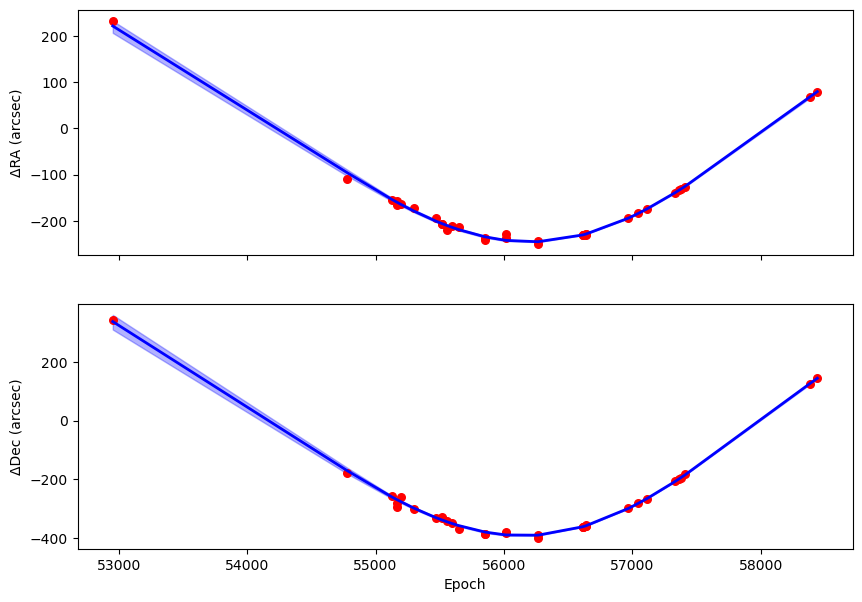

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1, figsize=(10,7), sharex=True)

# delta RA
axes[0].fill_between(epochs_grid, ra_q[0], ra_q[2], color="blue", alpha=0.3)
axes[0].plot(epochs_grid, ra_q[1], color="blue", lw=2)
axes[0].scatter(epochs_obs, delta_ra_obs, color="red", s=30)
axes[0].set_ylabel("ΔRA (arcsec)")

# delta Dec
axes[1].fill_between(epochs_grid, dec_q[0], dec_q[2], color="blue", alpha=0.3)
axes[1].plot(epochs_grid, dec_q[1], color="blue", lw=2)
axes[1].scatter(epochs_obs, delta_dec_obs, color="red", s=30)
axes[1].set_ylabel("ΔDec (arcsec)")
axes[1].set_xlabel("Epoch")


plt.show()


The observations lie well in the zone of confidence of the predictive checks. More than just concording with the observations, the created curve has the expected shape corresponding to an orbit.

# Revise

<div class="alert alert-success">
    
**Q11**. Discuss potential improvements and extensions to this analysis.
    
</div>

Giving the obtained results, a lot of improvements can be made. First of all, priors need to be further investigated. Indeed, some degeneration between the angles may be the origin of the faulted results. For example, because multiple angles describe the orbit, describing them with uniform priors may give rise to areas of preferences (near the poles probably). One of those distributions could be revised and change to improve that. An accurrate prior for the sma could also be found. My lack of knowledge in this area did not play in my favor but a distribution favorising only a given order of magnitude could be used. For example, changing the normal distribution for a distribution that is uniform around 10 but then decrease (without explicitely giving a peak around 10). In that case we would just define the zone in which we search without giving a clear estimate.\
\
These 2 ameliorations could help the exploration of the space during inference and correct for the the values stuck in a given area as well as the convergence of others.\
\
Of course the comparison with variational inference could still reveal new promising results.